# 3D U-Net for Brain Tumor Segmentation on BraTS 2021
Cleaned notebook: only the cells used for the manuscript (pipeline → metrics → figures).

## 1. Environment

In [1]:
import torch
import torchvision
import torchaudio
import monai

print("=== ENVIRONMENT CHECK ===")
print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("TorchAudio:", torchaudio.__version__)
print("MONAI:", monai.__version__)

print("\n=== CUDA CHECK ===")
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())
    print("GPU memory:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")

=== ENVIRONMENT CHECK ===
PyTorch: 2.8.0+cu128
TorchVision: 0.23.0+cu128
TorchAudio: 2.8.0+cu128
MONAI: 1.6.0

=== CUDA CHECK ===
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
GPU count: 1
GPU memory: 6.0 GB


In [3]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


## 2. Dataset download and extraction (BraTS 2021, Task 1)

In [11]:
import kagglehub

# Spécifier l'ID de la base de données pour BraTS 2021 (Tâche 1)
dataset_id = "dschettler8845/brats-2021-task1"

print("⏳ Téléchargement des données BraTS 2021 en cours, cela peut prendre un certain temps en raison de la taille importante...")
path = kagglehub.dataset_download(dataset_id)

print(f"✅ Téléchargement réussi ! Les fichiers sont situés dans le chemin suivant :\n{path}")

⏳ Téléchargement des données BraTS 2021 en cours, cela peut prendre un certain temps en raison de la taille importante...
Resuming download from 12157190144 bytes (1037583815 bytes left)...
Resuming download to C:\Users\eraze\.cache\kagglehub\datasets\dschettler8845\brats-2021-task1\1.archive (12157190144/13194773959) bytes left.


100%|█████████████████████████████████████████████████████████████████████████████| 12.3G/12.3G [06:01<00:00, 2.87MB/s]

Extracting files...


✅ Téléchargement réussi ! Les fichiers sont situés dans le chemin suivant :
C:\Users\eraze\.cache\kagglehub\datasets\dschettler8845\brats-2021-task1\versions\1


In [13]:
import tarfile
import os

tar_path = r"C:\Users\eraze\.cache\kagglehub\datasets\dschettler8845\brats-2021-task1\versions\1\BraTS2021_Training_Data.tar"

extract_path = r"C:\BraTS2021"

os.makedirs(extract_path, exist_ok=True)

with tarfile.open(tar_path, "r") as tar:
    tar.extractall(path=extract_path)

print("Extraction completed.")

Extraction completed.


## 3. Data split (70/15/15) and preprocessing

In [5]:
import os
from sklearn.model_selection import train_test_split

from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    NormalizeIntensityd,
    ResizeD,
    EnsureTyped
)

In [6]:
dataset_path = r"C:\BraTS2021"

patients = sorted([
    p for p in os.listdir(dataset_path)
    if p.startswith("BraTS2021_")
])

print("Total Patients:", len(patients))

Total Patients: 1251


In [7]:
data = []

for patient in patients:

    patient_path = os.path.join(dataset_path, patient)

    data.append({
        "image": [
            os.path.join(patient_path, f"{patient}_t1.nii.gz"),
            os.path.join(patient_path, f"{patient}_t1ce.nii.gz"),
            os.path.join(patient_path, f"{patient}_t2.nii.gz"),
            os.path.join(patient_path, f"{patient}_flair.nii.gz"),
        ],
        "label": os.path.join(patient_path, f"{patient}_seg.nii.gz"),
    })

print("Total Cases:", len(data))
print(data[0])

Total Cases: 1251
{'image': ['C:\\BraTS2021\\BraTS2021_00000\\BraTS2021_00000_t1.nii.gz', 'C:\\BraTS2021\\BraTS2021_00000\\BraTS2021_00000_t1ce.nii.gz', 'C:\\BraTS2021\\BraTS2021_00000\\BraTS2021_00000_t2.nii.gz', 'C:\\BraTS2021\\BraTS2021_00000\\BraTS2021_00000_flair.nii.gz'], 'label': 'C:\\BraTS2021\\BraTS2021_00000\\BraTS2021_00000_seg.nii.gz'}


In [8]:
train_files, test_files = train_test_split(
    data,
    test_size=0.15,
    random_state=42
)

train_files, val_files = train_test_split(
    train_files,
    test_size=0.1765,
    random_state=42
)

print("Training :", len(train_files))
print("Validation:", len(val_files))
print("Testing :", len(test_files))

Training : 875
Validation: 188
Testing : 188


In [39]:
import torch
from monai.transforms import MapTransform

class ConvertToMultiChannelBasedOnBratsClassesd(MapTransform):

    def __init__(self, keys):
        super().__init__(keys)

    def __call__(self, data):
        d = dict(data)

        for key in self.keys:

            label = d[key]

            if label.shape[0] == 1:
                label = label.squeeze(0)

            d[key] = torch.stack(
                [
                    ((label == 1) | (label == 2) | (label == 4)).float(),  # WT
                    ((label == 1) | (label == 4)).float(),                 # TC
                    (label == 4).float(),                                  # ET
                ],
                dim=0,
            )

        return d

In [40]:
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    NormalizeIntensityd,
    ResizeD,
    EnsureTyped,
)

train_transforms = Compose([

    LoadImaged(keys=["image", "label"]),

    EnsureChannelFirstd(keys=["image", "label"]),

    Orientationd(
        keys=["image", "label"],
        axcodes="RAS"
    ),

    NormalizeIntensityd(
        keys="image",
        nonzero=True,
        channel_wise=True
    ),

    ResizeD(
        keys=["image", "label"],
        spatial_size=(128, 128, 128),
        mode=("trilinear", "nearest")
    ),

    ConvertToMultiChannelBasedOnBratsClassesd(
        keys=["label"]
    ),

    EnsureTyped(
        keys=["image", "label"]
    )

])

In [58]:
from monai.data import Dataset

train_dataset = Dataset(
    data=train_files,
    transform=train_transforms
)

val_dataset = Dataset(
    data=val_files,
    transform=train_transforms
)

test_dataset = Dataset(
    data=test_files,
    transform=train_transforms
)

In [59]:
from monai.data import DataLoader

BATCH_SIZE = 1

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

## 4. Model (3D U-Net, MONAI)

In [52]:
import torch
from monai.networks.nets import UNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=3,
    channels=(32, 64, 128, 256, 512),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

print(model)
print("\nDevice:", device)

## 5. Training (Dice loss, Adam, AMP, checkpoint/resume)

In [33]:
from monai.losses import DiceLoss

criterion = DiceLoss(
    sigmoid=True,
    squared_pred=True,
    reduction="mean"
)

In [34]:
import torch

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

In [24]:
from torch import amp

scaler = amp.GradScaler("cuda")

In [63]:
import os
import time
import torch
from torch import amp

EPOCHS = 20

checkpoint_path = "checkpoint.pth"
best_model_path = "best_model.pth"

start_epoch = 0
best_val_loss = float("inf")

####################################################
# تحميل آخر Checkpoint إذا كان موجوداً
####################################################
if os.path.exists(checkpoint_path):

    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scaler.load_state_dict(checkpoint["scaler_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint["best_val_loss"]

    print("="*60)
    print(f"Resume training from Epoch {start_epoch+1}")
    print("="*60)

####################################################
# إذا لم يوجد Checkpoint ولكن يوجد أفضل نموذج
####################################################
elif os.path.exists(best_model_path):

    model.load_state_dict(torch.load(best_model_path, map_location=device))

    print("="*60)
    print("Loaded best_model.pth")
    print("Training will continue from this model.")
    print("="*60)

####################################################
# إذا لم يوجد شيء
####################################################
else:

    print("="*60)
    print("No checkpoint found.")
    print("Training from scratch.")
    print("="*60)

####################################################
# التدريب
####################################################
for epoch in range(start_epoch, EPOCHS):

    start_time = time.time()

    ##############################
    # TRAIN
    ##############################
    model.train()

    running_train_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):

        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with amp.autocast("cuda"):

            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_train_loss += loss.item()

        if (batch_idx + 1) % 20 == 0:

            print(
                f"Epoch [{epoch+1}/{EPOCHS}] "
                f"Batch [{batch_idx+1}/{len(train_loader)}] "
                f"Loss: {loss.item():.4f}"
            )

    avg_train_loss = running_train_loss / len(train_loader)

    ##############################
    # VALIDATION
    ##############################
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for batch in val_loader:

            images = batch["image"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)

            with amp.autocast("cuda"):

                outputs = model(images)
                loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)

    ##############################
    # حفظ أفضل نموذج
    ##############################
    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(model.state_dict(), best_model_path)

        print("Best model saved.")

    ##############################
    # حفظ Checkpoint
    ##############################
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_val_loss": best_val_loss,
    }, checkpoint_path)

    ##############################
    # ملخص الحقبة
    ##############################
    print("\n===================================================")
    print(f"Epoch           : {epoch+1}/{EPOCHS}")
    print(f"Train Loss      : {avg_train_loss:.4f}")
    print(f"Validation Loss : {avg_val_loss:.4f}")
    print(f"Best Val Loss   : {best_val_loss:.4f}")
    print(f"Time            : {time.time()-start_time:.1f} seconds")
    print("Checkpoint saved.")
    print("===================================================\n")

print("Training Finished.")

C:\Users\eraze\AppData\Local\Temp\ipykernel_21816\3804207891.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locat

Loaded best_model.pth
Training will continue from this model.
Epoch [1/20] Batch [20/875] Loss: 0.0866
Epoch [1/20] Batch [40/875] Loss: 0.3505
Epoch [1/20] Batch [60/875] Loss: 0.1236
Epoch [1/20] Batch [80/875] Loss: 0.1556
Epoch [1/20] Batch [100/875] Loss: 0.4866
Epoch [1/20] Batch [120/875] Loss: 0.3789
Epoch [1/20] Batch [140/875] Loss: 0.1335
Epoch [1/20] Batch [160/875] Loss: 0.2519
Epoch [1/20] Batch [180/875] Loss: 0.1993
Epoch [1/20] Batch [200/875] Loss: 0.1169
Epoch [1/20] Batch [220/875] Loss: 0.2738
Epoch [1/20] Batch [240/875] Loss: 0.3465
Epoch [1/20] Batch [260/875] Loss: 0.3245
Epoch [1/20] Batch [280/875] Loss: 0.1481
Epoch [1/20] Batch [300/875] Loss: 0.1193
Epoch [1/20] Batch [320/875] Loss: 0.1081
Epoch [1/20] Batch [340/875] Loss: 0.2364
Epoch [1/20] Batch [360/875] Loss: 0.1300
Epoch [1/20] Batch [380/875] Loss: 0.0909
Epoch [1/20] Batch [400/875] Loss: 0.1064
Epoch [1/20] Batch [420/875] Loss: 0.1730
Epoch [1/20] Batch [440/875] Loss: 0.0515
Epoch [1/20] Batch

## 6. Load best model

In [39]:
import torch
from monai.networks.nets import UNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# إنشاء نفس بنية النموذج التي تم التدريب عليها
model = UNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=3,
    channels=(32, 64, 128, 256, 512),
    strides=(2, 2, 2, 2),
    num_res_units=2
).to(device)

# تحميل النموذج المدرّب مباشرة
checkpoint = torch.load(
    "best_model.pth",
    map_location=device,
    weights_only=True
)

model.load_state_dict(checkpoint)
model.eval()

print("Device:", device)
print("Model loaded:", type(model).__name__)
print("Best model loaded successfully.")

Device: cuda
Model loaded: UNet
Best model loaded successfully.


## 7. Native-space evaluation on the test set (Dice, HD95)

In [69]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import nibabel as nib

from scipy.ndimage import binary_erosion, distance_transform_edt


# ============================================================
# SETTINGS
# ============================================================

NATIVE_SIZE = (240, 240, 155)
NATIVE_SPACING = (1.0, 1.0, 1.0)
THRESHOLD = 0.5


# ============================================================
# DICE
# ============================================================

def dice_score(pred, gt):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    pred_sum = pred.sum()
    gt_sum = gt.sum()

    if pred_sum == 0 and gt_sum == 0:
        return 1.0

    if pred_sum == 0 or gt_sum == 0:
        return 0.0

    intersection = np.logical_and(pred, gt).sum()

    return (
        2.0 * intersection
        / (pred_sum + gt_sum)
    )


# ============================================================
# HD95
# ============================================================

def hd95(pred, gt, spacing=(1.0, 1.0, 1.0)):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    # Both empty
    if not pred.any() and not gt.any():
        return 0.0

    # One empty
    if not pred.any() or not gt.any():
        return np.nan

    pred_surface = pred ^ binary_erosion(pred)
    gt_surface = gt ^ binary_erosion(gt)

    dt_gt = distance_transform_edt(
        ~gt_surface,
        sampling=spacing
    )

    dt_pred = distance_transform_edt(
        ~pred_surface,
        sampling=spacing
    )

    distances_pred_to_gt = dt_gt[pred_surface]
    distances_gt_to_pred = dt_pred[gt_surface]

    distances = np.concatenate([
        distances_pred_to_gt,
        distances_gt_to_pred
    ])

    return np.percentile(distances, 95)


# ============================================================
# LOAD NATIVE LABEL IN RAS
# ============================================================

def load_native_label_ras(label_path):

    nii = nib.load(label_path)

    # Convert original orientation -> RAS
    nii_ras = nib.as_closest_canonical(nii)

    label = nii_ras.get_fdata()

    label = np.squeeze(label)

    # Check native dimensions
    if label.shape != NATIVE_SIZE:

        raise ValueError(
            f"Unexpected native shape: {label.shape}, "
            f"expected {NATIVE_SIZE}"
        )

    # Check native spacing
    spacing = nii_ras.header.get_zooms()[:3]

    print("Native RAS shape:", label.shape)
    print("Native RAS spacing:", spacing)

    return label


# ============================================================
# BRATS REGIONS
# ============================================================

def get_brats_regions(label):

    WT = (
        (label == 1) |
        (label == 2) |
        (label == 4)
    )

    TC = (
        (label == 1) |
        (label == 4)
    )

    ET = (
        label == 4
    )

    return WT, TC, ET


# ============================================================
# EVALUATION
# ============================================================

model.eval()

results = []


with torch.no_grad():

    for patient_id, batch in enumerate(test_loader):

        print("\n======================================")
        print(f"Patient {patient_id + 1:03d}")
        print("======================================")

        # ----------------------------------------------------
        # IMAGE
        # ----------------------------------------------------

        image = batch["image"].to(device)

        # ----------------------------------------------------
        # MODEL
        # ----------------------------------------------------

        output = model(image)

        probabilities = torch.sigmoid(output)

        print(
            "Probability shape:",
            tuple(probabilities.shape)
        )

        # ----------------------------------------------------
        # RESIZE PROBABILITIES
        #
        # 128³ -> 240×240×155
        #
        # IMPORTANT:
        # interpolation is applied BEFORE threshold
        # ----------------------------------------------------

        probabilities_native = F.interpolate(
            probabilities,
            size=NATIVE_SIZE,
            mode="trilinear",
            align_corners=False
        )

        # ----------------------------------------------------
        # THRESHOLD IN NATIVE SPACE
        # ----------------------------------------------------

        prediction_native = (
            probabilities_native > THRESHOLD
        )

        prediction_native = (
            prediction_native
            .cpu()
            .numpy()[0]
        )

        # ----------------------------------------------------
        # ORIGINAL LABEL PATH
        # ----------------------------------------------------

        label_path = (
            batch["label"]
            .meta["filename_or_obj"]
        )

        if isinstance(label_path, (list, tuple)):
            label_path = label_path[0]

        print("Label:", label_path)

        # ----------------------------------------------------
        # LOAD NATIVE LABEL AND CONVERT TO RAS
        # ----------------------------------------------------

        native_label = load_native_label_ras(
            label_path
        )

        # ----------------------------------------------------
        # CREATE WT / TC / ET
        # ----------------------------------------------------

        gt_WT, gt_TC, gt_ET = get_brats_regions(
            native_label
        )

        # ----------------------------------------------------
        # PREDICTION CHANNELS
        # ----------------------------------------------------

        pred_WT = prediction_native[0]
        pred_TC = prediction_native[1]
        pred_ET = prediction_native[2]

        # ----------------------------------------------------
        # DICE
        # ----------------------------------------------------

        dice_WT = dice_score(
            pred_WT,
            gt_WT
        )

        dice_TC = dice_score(
            pred_TC,
            gt_TC
        )

        dice_ET = dice_score(
            pred_ET,
            gt_ET
        )

        # ----------------------------------------------------
        # HD95
        # ----------------------------------------------------

        hd_WT = hd95(
            pred_WT,
            gt_WT,
            NATIVE_SPACING
        )

        hd_TC = hd95(
            pred_TC,
            gt_TC,
            NATIVE_SPACING
        )

        hd_ET = hd95(
            pred_ET,
            gt_ET,
            NATIVE_SPACING
        )

        # ----------------------------------------------------
        # VOLUMES
        #
        # 1 voxel = 1 mm³
        # ----------------------------------------------------

        pred_WT_volume_cm3 = (
            pred_WT.sum() / 1000.0
        )

        pred_TC_volume_cm3 = (
            pred_TC.sum() / 1000.0
        )

        pred_ET_volume_cm3 = (
            pred_ET.sum() / 1000.0
        )

        gt_WT_volume_cm3 = (
            gt_WT.sum() / 1000.0
        )

        gt_TC_volume_cm3 = (
            gt_TC.sum() / 1000.0
        )

        gt_ET_volume_cm3 = (
            gt_ET.sum() / 1000.0
        )

        # ----------------------------------------------------
        # SAVE
        # ----------------------------------------------------

        results.append([
            patient_id + 1,

            dice_WT,
            dice_TC,
            dice_ET,

            hd_WT,
            hd_TC,
            hd_ET,

            pred_WT_volume_cm3,
            pred_TC_volume_cm3,
            pred_ET_volume_cm3,

            gt_WT_volume_cm3,
            gt_TC_volume_cm3,
            gt_ET_volume_cm3
        ])

        # ----------------------------------------------------
        # PRINT
        # ----------------------------------------------------

        print(
            f"WT | DSC={dice_WT:.4f} | "
            f"HD95={hd_WT:.2f} mm | "
            f"PredVol={pred_WT_volume_cm3:.2f} cm³"
        )

        print(
            f"TC | DSC={dice_TC:.4f} | "
            f"HD95={hd_TC:.2f} mm | "
            f"PredVol={pred_TC_volume_cm3:.2f} cm³"
        )

        print(
            f"ET | DSC={dice_ET:.4f} | "
            f"HD95={hd_ET:.2f} mm | "
            f"PredVol={pred_ET_volume_cm3:.2f} cm³"
        )


# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(
    results,
    columns=[
        "Patient",

        "DSC_WT",
        "DSC_TC",
        "DSC_ET",

        "HD95_WT_mm",
        "HD95_TC_mm",
        "HD95_ET_mm",

        "Pred_Volume_WT_cm3",
        "Pred_Volume_TC_cm3",
        "Pred_Volume_ET_cm3",

        "GT_Volume_WT_cm3",
        "GT_Volume_TC_cm3",
        "GT_Volume_ET_cm3"
    ]
)


# ============================================================
# SAVE
# ============================================================

df.to_csv(
    "Native_Space_Metrics_WT_TC_ET.csv",
    index=False
)


# ============================================================
# FINAL STATISTICS
# ============================================================

print("\n======================================")
print("NATIVE-SPACE FINAL RESULTS")
print("======================================")


print("\nMean DSC")
print(f"WT : {df['DSC_WT'].mean():.4f}")
print(f"TC : {df['DSC_TC'].mean():.4f}")
print(f"ET : {df['DSC_ET'].mean():.4f}")


print("\nSD DSC")
print(f"WT : {df['DSC_WT'].std():.4f}")
print(f"TC : {df['DSC_TC'].std():.4f}")
print(f"ET : {df['DSC_ET'].std():.4f}")


print("\nMean HD95")
print(f"WT : {df['HD95_WT_mm'].mean():.4f} mm")
print(f"TC : {df['HD95_TC_mm'].mean():.4f} mm")
print(f"ET : {df['HD95_ET_mm'].mean():.4f} mm")


print("\nSD HD95")
print(f"WT : {df['HD95_WT_mm'].std():.4f} mm")
print(f"TC : {df['HD95_TC_mm'].std():.4f} mm")
print(f"ET : {df['HD95_ET_mm'].std():.4f} mm")


print("\nMean Predicted Volumes")
print(
    f"WT : {df['Pred_Volume_WT_cm3'].mean():.4f} cm³"
)
print(
    f"TC : {df['Pred_Volume_TC_cm3'].mean():.4f} cm³"
)
print(
    f"ET : {df['Pred_Volume_ET_cm3'].mean():.4f} cm³"
)


print("\n======================================")
print("Saved:")
print("Native_Space_Metrics_WT_TC_ET.csv")
print("======================================")


Patient 001
Probability shape: (1, 3, 128, 128, 128)
Label: C:\BraTS2021\BraTS2021_01137\BraTS2021_01137_seg.nii.gz
Native RAS shape: (240, 240, 155)
Native RAS spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
WT | DSC=0.9267 | HD95=2.00 mm | PredVol=39.18 cm³
TC | DSC=0.8519 | HD95=3.00 mm | PredVol=12.70 cm³
ET | DSC=0.6870 | HD95=5.83 mm | PredVol=8.06 cm³

Patient 002
Probability shape: (1, 3, 128, 128, 128)
Label: C:\BraTS2021\BraTS2021_01659\BraTS2021_01659_seg.nii.gz
Native RAS shape: (240, 240, 155)
Native RAS spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
WT | DSC=0.9247 | HD95=2.24 mm | PredVol=143.81 cm³
TC | DSC=0.9252 | HD95=2.24 mm | PredVol=71.34 cm³
ET | DSC=0.9046 | HD95=2.00 mm | PredVol=61.91 cm³

Patient 003
Probability shape: (1, 3, 128, 128, 128)
Label: C:\BraTS2021\BraTS2021_01483\BraTS2021_01483_seg.nii.gz
Native RAS shape: (240, 240, 155)
Native RAS spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
WT | DSC=0.8759 | HD95=5.

In [48]:
import pandas as pd

df = pd.read_csv("Native_Space_Metrics_WT_TC_ET.csv")

print("=" * 70)
print("J2 — TEST SET: EMPTY / NON-EMPTY CASES")
print("=" * 70)

for region in ["WT", "TC", "ET"]:

    gt = df[f"GT_Volume_{region}_cm3"]
    pred = df[f"Pred_Volume_{region}_cm3"]

    both_empty = (gt == 0) & (pred == 0)
    fp = (gt == 0) & (pred > 0)
    fn = (gt > 0) & (pred == 0)
    both_nonempty = (gt > 0) & (pred > 0)

    print(f"\n===== {region} =====")
    print(f"Both empty       : {both_empty.sum()} / 188")
    print(f"FP (GT empty)    : {fp.sum()} / 188")
    print(f"FN (Pred empty)  : {fn.sum()} / 188")
    print(f"Both non-empty   : {both_nonempty.sum()} / 188")

    if fp.sum() > 0:
        print("FP patients:", df.loc[fp, "Patient"].tolist())

    if fn.sum() > 0:
        print("FN patients:", df.loc[fn, "Patient"].tolist())

print("\n" + "=" * 70)

J2 — TEST SET: EMPTY / NON-EMPTY CASES

===== WT =====
Both empty       : 0 / 188
FP (GT empty)    : 0 / 188
FN (Pred empty)  : 0 / 188
Both non-empty   : 188 / 188

===== TC =====
Both empty       : 0 / 188
FP (GT empty)    : 0 / 188
FN (Pred empty)  : 1 / 188
Both non-empty   : 187 / 188
FN patients: [12]

===== ET =====
Both empty       : 2 / 188
FP (GT empty)    : 2 / 188
FN (Pred empty)  : 1 / 188
Both non-empty   : 183 / 188
FP patients: [3, 46]
FN patients: [12]



In [49]:
import pandas as pd
import numpy as np

# ============================================================
# J4 — 95% CONFIDENCE INTERVALS BY PATIENT-LEVEL BOOTSTRAP
# ============================================================

CSV_PATH = "Native_Space_Metrics_WT_TC_ET.csv"

# عدد bootstrap replicates
N_BOOTSTRAP = 10000

# Seed لإعادة إنتاج النتيجة نفسها
RANDOM_SEED = 42

# ------------------------------------------------------------
# 1. Load data
# ------------------------------------------------------------

df = pd.read_csv(CSV_PATH)

print("=" * 70)
print("J4 — 95% CONFIDENCE INTERVALS")
print("=" * 70)

print(f"Number of patients: {len(df)}")
print("\nColumns:")
print(df.columns.tolist())


# ------------------------------------------------------------
# 2. Patient-level DSC
# ------------------------------------------------------------

dsc_cols = [
    "DSC_WT",
    "DSC_TC",
    "DSC_ET"
]

# DSC moyen لكل patient عبر WT, TC, ET
df["DSC_patient_mean"] = df[dsc_cols].mean(axis=1)

dsc_values = df["DSC_patient_mean"].dropna().to_numpy()


# ------------------------------------------------------------
# 3. Patient-level HD95
# ------------------------------------------------------------

hd95_cols = [
    "HD95_WT_mm",
    "HD95_TC_mm",
    "HD95_ET_mm"
]

# HD95 moyen لكل patient عبر WT, TC, ET
df["HD95_patient_mean"] = df[hd95_cols].mean(axis=1)

hd95_values = df["HD95_patient_mean"].dropna().to_numpy()


# ------------------------------------------------------------
# 4. Bootstrap function
# ------------------------------------------------------------

def bootstrap_mean_ci(values, n_bootstrap=10000, seed=42):

    rng = np.random.default_rng(seed)

    n = len(values)

    bootstrap_means = np.empty(n_bootstrap)

    for i in range(n_bootstrap):

        sample = rng.choice(
            values,
            size=n,
            replace=True
        )

        bootstrap_means[i] = np.mean(sample)

    mean_value = np.mean(values)

    ci_lower = np.percentile(
        bootstrap_means,
        2.5
    )

    ci_upper = np.percentile(
        bootstrap_means,
        97.5
    )

    return mean_value, ci_lower, ci_upper


# ------------------------------------------------------------
# 5. Calculate DSC CI
# ------------------------------------------------------------

dsc_mean, dsc_ci_low, dsc_ci_high = bootstrap_mean_ci(
    dsc_values,
    n_bootstrap=N_BOOTSTRAP,
    seed=RANDOM_SEED
)


# ------------------------------------------------------------
# 6. Calculate HD95 CI
# ------------------------------------------------------------

hd95_mean, hd95_ci_low, hd95_ci_high = bootstrap_mean_ci(
    hd95_values,
    n_bootstrap=N_BOOTSTRAP,
    seed=RANDOM_SEED
)


# ------------------------------------------------------------
# 7. Display results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DSC — PATIENT LEVEL")
print("=" * 70)

print(f"Mean DSC       : {dsc_mean:.4f}")
print(f"95% CI         : {dsc_ci_low:.4f} – {dsc_ci_high:.4f}")


print("\n" + "=" * 70)
print("HD95 — PATIENT LEVEL")
print("=" * 70)

print(f"Mean HD95      : {hd95_mean:.4f} mm")
print(f"95% CI         : {hd95_ci_low:.4f} – {hd95_ci_high:.4f} mm")


print("\n" + "=" * 70)
print("J4 COMPLETE")
print("=" * 70)

J4 — 95% CONFIDENCE INTERVALS
Number of patients: 188

Columns:
['Patient', 'DSC_WT', 'DSC_TC', 'DSC_ET', 'HD95_WT_mm', 'HD95_TC_mm', 'HD95_ET_mm', 'Pred_Volume_WT_cm3', 'Pred_Volume_TC_cm3', 'Pred_Volume_ET_cm3', 'GT_Volume_WT_cm3', 'GT_Volume_TC_cm3', 'GT_Volume_ET_cm3']

DSC — PATIENT LEVEL
Mean DSC       : 0.8076
95% CI         : 0.7889 – 0.8250

HD95 — PATIENT LEVEL
Mean HD95      : 6.4924 mm
95% CI         : 5.4534 – 7.6889 mm

J4 COMPLETE


In [51]:
import pandas as pd
import numpy as np

# ============================================================
# J4 — HD95 95% CI WITH 373.13 mm PENALTY
# ============================================================

CSV_PATH = "Native_Space_Metrics_WT_TC_ET.csv"

PENALTY = 373.13
N_BOOTSTRAP = 10000
SEED = 42

df = pd.read_csv(CSV_PATH)

# ------------------------------------------------------------
# 1. Build patient-level HD95
# ------------------------------------------------------------

hd_cols = [
    "HD95_WT_mm",
    "HD95_TC_mm",
    "HD95_ET_mm"
]

# عدد الحالات penalty المعروف من J2
# WT = 0
# TC = 1
# ET = 3

# نعوّض NaN الموجودة في هذه الأعمدة بالـ penalty
# لأن J2 أثبت أن هذه الـ NaN هي حالات penalty.
for col in hd_cols:
    df[col] = df[col].fillna(PENALTY)

# متوسط HD95 للمريض عبر WT/TC/ET
df["HD95_patient_mean"] = df[hd_cols].mean(axis=1)

values = df["HD95_patient_mean"].to_numpy()

print("=" * 70)
print("J4 — HD95 WITH 373.13 mm PENALTY")
print("=" * 70)

print(f"Patients: {len(values)}")
print(f"Penalty: {PENALTY} mm")

print(f"\nMean HD95   : {np.mean(values):.4f} mm")
print(f"Median HD95 : {np.median(values):.4f} mm")

q1 = np.percentile(values, 25)
q3 = np.percentile(values, 75)

print(f"Q1          : {q1:.4f} mm")
print(f"Q3          : {q3:.4f} mm")
print(f"IQR         : {q3-q1:.4f} mm")


# ------------------------------------------------------------
# 2. Patient-level bootstrap
# ------------------------------------------------------------

rng = np.random.default_rng(SEED)

n = len(values)

bootstrap_means = np.empty(N_BOOTSTRAP)

for i in range(N_BOOTSTRAP):

    sample = rng.choice(
        values,
        size=n,
        replace=True
    )

    bootstrap_means[i] = np.mean(sample)


# ------------------------------------------------------------
# 3. 95% CI
# ------------------------------------------------------------

ci_low = np.percentile(
    bootstrap_means,
    2.5
)

ci_high = np.percentile(
    bootstrap_means,
    97.5
)


# ------------------------------------------------------------
# 4. Final result
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL J1 + J4")
print("=" * 70)

print(f"Mean HD95       : {np.mean(values):.4f} mm")
print(f"Median HD95     : {np.median(values):.4f} mm")
print(f"Q1              : {q1:.4f} mm")
print(f"Q3              : {q3:.4f} mm")
print(f"IQR             : {q3-q1:.4f} mm")
print(f"95% CI          : {ci_low:.4f} – {ci_high:.4f} mm")

print("\n" + "=" * 70)
print("J4 COMPLETE")
print("=" * 70)

J4 — HD95 WITH 373.13 mm PENALTY
Patients: 188
Penalty: 373.13 mm

Mean HD95   : 9.0416 mm
Median HD95 : 3.5899 mm
Q1          : 2.5380 mm
Q3          : 7.7192 mm
IQR         : 5.1812 mm

FINAL J1 + J4
Mean HD95       : 9.0416 mm
Median HD95     : 3.5899 mm
Q1              : 2.5380 mm
Q3              : 7.7192 mm
IQR             : 5.1812 mm
95% CI          : 6.1884 – 12.9486 mm

J4 COMPLETE


## 8. Validation and training sets (native space)

In [42]:
# ============================================================
# H1 — VALIDATION ONLY — NATIVE SPACE
# 188 PATIENTS
# ============================================================

import numpy as np
import pandas as pd
import torch
from scipy.ndimage import zoom, distance_transform_edt
from tqdm.auto import tqdm
import time

# ============================================================
# 1. SETTINGS
# ============================================================

NATIVE_SHAPE = (240, 240, 155)
EMPTY_MASK_PENALTY = 373.13

print("=" * 70)
print("H1 — VALIDATION NATIVE-SPACE EVALUATION")
print("=" * 70)

print("Device:", device)
print("Native shape:", NATIVE_SHAPE)
print("Empty-mask HD95 penalty:", EMPTY_MASK_PENALTY, "mm")
print("Validation patients:", len(val_loader))

# ============================================================
# 2. MODEL
# ============================================================

model = model.to(device)
model.eval()

print("Model:", type(model).__name__)
print("Model ready.")
print()

# ============================================================
# 3. BRATS LABEL → WT / TC / ET
# ============================================================

def brats_to_regions(label_3d):

    # WT = labels 1, 2, 4
    WT = label_3d > 0

    # TC = labels 1 and 4
    TC = np.logical_or(
        label_3d == 1,
        label_3d == 4
    )

    # ET = label 4
    ET = label_3d == 4

    return WT, TC, ET


# ============================================================
# 4. RESIZE 128³ → NATIVE 240×240×155
# ============================================================

def to_native(mask):

    factors = (
        NATIVE_SHAPE[0] / mask.shape[0],
        NATIVE_SHAPE[1] / mask.shape[1],
        NATIVE_SHAPE[2] / mask.shape[2]
    )

    native = zoom(
        mask.astype(np.uint8),
        factors,
        order=0
    )

    return native.astype(bool)


# ============================================================
# 5. DICE
# ============================================================

def dice_score(pred, target):

    pred = pred.astype(bool)
    target = target.astype(bool)

    pred_sum = pred.sum()
    target_sum = target.sum()

    # Both empty
    if pred_sum == 0 and target_sum == 0:
        return 1.0

    # Only one empty
    if pred_sum == 0 or target_sum == 0:
        return 0.0

    intersection = np.logical_and(
        pred,
        target
    ).sum()

    return (
        2.0 * intersection
        / (pred_sum + target_sum)
    )


# ============================================================
# 6. MEMORY-SAFE HD95
# ============================================================

def hd95_binary(pred, target):

    pred = pred.astype(bool)
    target = target.astype(bool)

    pred_empty = not pred.any()
    target_empty = not target.any()

    # Both empty
    if pred_empty and target_empty:
        return 0.0

    # One empty → reviewer penalty
    if pred_empty or target_empty:
        return EMPTY_MASK_PENALTY

    # --------------------------------------------------------
    # Distance transform
    # No pairwise distance matrix
    # --------------------------------------------------------

    distance_to_target = distance_transform_edt(
        ~target
    )

    distance_to_pred = distance_transform_edt(
        ~pred
    )

    pred_to_target = distance_to_target[pred]
    target_to_pred = distance_to_pred[target]

    all_distances = np.concatenate(
        [
            pred_to_target,
            target_to_pred
        ]
    )

    return float(
        np.percentile(
            all_distances,
            95
        )
    )


# ============================================================
# 7. VALIDATION EVALUATION
# ============================================================

results = []

region_names = [
    "WT",
    "TC",
    "ET"
]

start_time = time.time()

print()
print("Starting validation evaluation...")
print()

with torch.no_grad():

    for patient_idx, batch in enumerate(
        tqdm(
            val_loader,
            total=len(val_loader),
            desc="Validation native-space"
        )
    ):

        # ----------------------------------------------------
        # IMAGE
        # ----------------------------------------------------

        image = batch["image"].to(device)

        # ----------------------------------------------------
        # ORIGINAL BRATS LABEL
        # [1,1,128,128,128]
        # ----------------------------------------------------

        label = batch["label"]

        label_128 = (
            label[0, 0]
            .detach()
            .cpu()
            .numpy()
        )

        # ----------------------------------------------------
        # MODEL PREDICTION
        # ----------------------------------------------------

        output = model(image)

        prediction = (
            torch.sigmoid(output) > 0.5
        )

        prediction_128 = (
            prediction[0]
            .detach()
            .cpu()
            .numpy()
        )

        # ----------------------------------------------------
        # CONVERT TARGET TO WT / TC / ET
        # ----------------------------------------------------

        WT_target, TC_target, ET_target = \
            brats_to_regions(label_128)

        targets = [
            WT_target,
            TC_target,
            ET_target
        ]

        # ----------------------------------------------------
        # PATIENT RESULT
        # ----------------------------------------------------

        patient_result = {
            "Patient": patient_idx + 1
        }

        patient_dice = []
        patient_hd95 = []

        # ----------------------------------------------------
        # WT / TC / ET
        # ----------------------------------------------------

        for channel, region_name in enumerate(
            region_names
        ):

            pred_128 = (
                prediction_128[channel]
                .astype(bool)
            )

            target_128 = (
                targets[channel]
                .astype(bool)
            )

            # ------------------------------------------------
            # Convert to native space
            # ------------------------------------------------

            pred_native = to_native(
                pred_128
            )

            target_native = to_native(
                target_128
            )

            # ------------------------------------------------
            # Dice
            # ------------------------------------------------

            dice = dice_score(
                pred_native,
                target_native
            )

            # ------------------------------------------------
            # HD95
            # ------------------------------------------------

            hd95 = hd95_binary(
                pred_native,
                target_native
            )

            # ------------------------------------------------
            # Save region results
            # ------------------------------------------------

            patient_result[
                f"{region_name}_Dice"
            ] = dice

            patient_result[
                f"{region_name}_HD95_mm"
            ] = hd95

            patient_dice.append(dice)
            patient_hd95.append(hd95)

        # ----------------------------------------------------
        # Patient average over WT / TC / ET
        # ----------------------------------------------------

        patient_result[
            "Patient_Dice"
        ] = float(
            np.mean(patient_dice)
        )

        patient_result[
            "Patient_HD95_mm"
        ] = float(
            np.mean(patient_hd95)
        )

        results.append(
            patient_result
        )

        # ----------------------------------------------------
        # SAVE PROGRESS EVERY 25 PATIENTS
        # ----------------------------------------------------

        if len(results) % 25 == 0:

            temporary_df = pd.DataFrame(
                results
            )

            temporary_df.to_csv(
                "Native_Space_Validation_188_progress.csv",
                index=False
            )


# ============================================================
# 8. FINAL DATAFRAME
# ============================================================

val_native_df = pd.DataFrame(
    results
)

# ============================================================
# 9. FINAL SAVE
# ============================================================

output_file = (
    "Native_Space_Validation_188.csv"
)

val_native_df.to_csv(
    output_file,
    index=False
)

# ============================================================
# 10. STATISTICS — H1 / J1
# ============================================================

mean_dice = (
    val_native_df["Patient_Dice"].mean()
)

median_dice = (
    val_native_df["Patient_Dice"].median()
)

std_dice = (
    val_native_df["Patient_Dice"].std()
)

mean_hd95 = (
    val_native_df["Patient_HD95_mm"].mean()
)

median_hd95 = (
    val_native_df["Patient_HD95_mm"].median()
)

q1_hd95 = (
    val_native_df["Patient_HD95_mm"]
    .quantile(0.25)
)

q3_hd95 = (
    val_native_df["Patient_HD95_mm"]
    .quantile(0.75)
)

iqr_hd95 = q3_hd95 - q1_hd95

# ============================================================
# 11. PENALIZED CASES — J2
# ============================================================

penalty_WT = (
    val_native_df["WT_HD95_mm"]
    == EMPTY_MASK_PENALTY
).sum()

penalty_TC = (
    val_native_df["TC_HD95_mm"]
    == EMPTY_MASK_PENALTY
).sum()

penalty_ET = (
    val_native_df["ET_HD95_mm"]
    == EMPTY_MASK_PENALTY
).sum()

penalty_patient = (
    val_native_df["Patient_HD95_mm"]
    == EMPTY_MASK_PENALTY
).sum()

# ============================================================
# 12. TIME
# ============================================================

elapsed = time.time() - start_time

minutes = elapsed / 60

# ============================================================
# 13. DISPLAY FINAL RESULTS
# ============================================================

print()
print("=" * 70)
print("H1 — VALIDATION RESULTS")
print("=" * 70)

print("Patients evaluated:", len(val_native_df))

print()
print("DICE")
print("----------------------------------------")
print(f"Mean Dice   : {mean_dice:.4f}")
print(f"Median Dice : {median_dice:.4f}")
print(f"Std Dice    : {std_dice:.4f}")

print()
print("HD95 — NATIVE SPACE")
print("----------------------------------------")
print(f"Mean HD95   : {mean_hd95:.4f} mm")
print(f"Median HD95 : {median_hd95:.4f} mm")
print(f"Q1          : {q1_hd95:.4f} mm")
print(f"Q3          : {q3_hd95:.4f} mm")
print(f"IQR         : {iqr_hd95:.4f} mm")

print()
print("J2 — PENALIZED CASES")
print("----------------------------------------")
print(
    f"WT: {penalty_WT} / {len(val_native_df)}"
)
print(
    f"TC: {penalty_TC} / {len(val_native_df)}"
)
print(
    f"ET: {penalty_ET} / {len(val_native_df)}"
)
print(
    f"Patients with Patient-HD95 penalty: "
    f"{penalty_patient} / {len(val_native_df)}"
)

print()
print("TIME")
print("----------------------------------------")
print(f"Elapsed time: {minutes:.1f} minutes")

print()
print("Saved:")
print(output_file)

print()
print("=" * 70)
print("VALIDATION COMPLETE")
print("=" * 70)

H1 — VALIDATION NATIVE-SPACE EVALUATION
Device: cuda
Native shape: (240, 240, 155)
Empty-mask HD95 penalty: 373.13 mm
Validation patients: 188
Model: UNet
Model ready.


Starting validation evaluation...



Validation native-space:   0%|          | 0/188 [00:00<?, ?it/s]


H1 — VALIDATION RESULTS
Patients evaluated: 188

DICE
----------------------------------------
Mean Dice   : 0.8346
Median Dice : 0.8911
Std Dice    : 0.1407

HD95 — NATIVE SPACE
----------------------------------------
Mean HD95   : 8.3721 mm
Median HD95 : 1.1381 mm
Q1          : 1.0000 mm
Q3          : 2.7103 mm
IQR         : 1.7103 mm

J2 — PENALIZED CASES
----------------------------------------
WT: 0 / 188
TC: 4 / 188
ET: 4 / 188
Patients with Patient-HD95 penalty: 0 / 188

TIME
----------------------------------------
Elapsed time: 30.5 minutes

Saved:
Native_Space_Validation_188.csv

VALIDATION COMPLETE


In [43]:
# ============================================================
# H1 — TRAINING: DSC ONLY IN NATIVE SPACE
# 875 PATIENTS
# ============================================================

import numpy as np
import pandas as pd
import torch
from scipy.ndimage import zoom
from tqdm.auto import tqdm
import time

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

NATIVE_SHAPE = (240, 240, 155)

model.eval()
model = model.to(device)

print("=" * 70)
print("H1 — TRAINING DSC NATIVE SPACE")
print("=" * 70)
print("Patients:", len(train_loader))
print("Device:", device)

# ------------------------------------------------------------
# BraTS label → WT / TC / ET
# ------------------------------------------------------------

def brats_to_regions(label_3d):

    WT = label_3d > 0

    TC = np.logical_or(
        label_3d == 1,
        label_3d == 4
    )

    ET = label_3d == 4

    return WT, TC, ET


# ------------------------------------------------------------
# 128³ → native 240×240×155
# ------------------------------------------------------------

def to_native(mask):

    factors = (
        NATIVE_SHAPE[0] / mask.shape[0],
        NATIVE_SHAPE[1] / mask.shape[1],
        NATIVE_SHAPE[2] / mask.shape[2]
    )

    return zoom(
        mask.astype(np.uint8),
        factors,
        order=0
    ).astype(bool)


# ------------------------------------------------------------
# Dice
# ------------------------------------------------------------

def dice_score(pred, target):

    pred = pred.astype(bool)
    target = target.astype(bool)

    pred_sum = pred.sum()
    target_sum = target.sum()

    # Both empty
    if pred_sum == 0 and target_sum == 0:
        return 1.0

    # One empty
    if pred_sum == 0 or target_sum == 0:
        return 0.0

    intersection = np.logical_and(
        pred,
        target
    ).sum()

    return (
        2.0 * intersection
        / (pred_sum + target_sum)
    )


# ============================================================
# EVALUATION
# ============================================================

results = []

region_names = ["WT", "TC", "ET"]

start_time = time.time()

with torch.no_grad():

    for patient_idx, batch in enumerate(
        tqdm(
            train_loader,
            total=len(train_loader),
            desc="Training DSC native-space"
        )
    ):

        # ----------------------------------------------------
        # Image
        # ----------------------------------------------------

        image = batch["image"].to(device)

        # ----------------------------------------------------
        # Label
        # ----------------------------------------------------

        label = batch["label"]

        label_128 = (
            label[0, 0]
            .detach()
            .cpu()
            .numpy()
        )

        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        output = model(image)

        prediction = (
            torch.sigmoid(output) > 0.5
        )

        prediction_128 = (
            prediction[0]
            .detach()
            .cpu()
            .numpy()
        )

        # ----------------------------------------------------
        # Target regions
        # ----------------------------------------------------

        WT_target, TC_target, ET_target = \
            brats_to_regions(label_128)

        targets = [
            WT_target,
            TC_target,
            ET_target
        ]

        patient_result = {
            "Patient": patient_idx + 1
        }

        dice_values = []

        # ----------------------------------------------------
        # WT / TC / ET
        # ----------------------------------------------------

        for channel, region_name in enumerate(
            region_names
        ):

            pred_128 = (
                prediction_128[channel]
                .astype(bool)
            )

            target_128 = (
                targets[channel]
                .astype(bool)
            )

            # Native space
            pred_native = to_native(pred_128)
            target_native = to_native(target_128)

            # Dice
            dice = dice_score(
                pred_native,
                target_native
            )

            patient_result[
                f"{region_name}_Dice"
            ] = dice

            dice_values.append(dice)

        # ----------------------------------------------------
        # Mean Dice for this patient
        # ----------------------------------------------------

        patient_result[
            "Patient_Dice"
        ] = float(
            np.mean(dice_values)
        )

        results.append(patient_result)

        # ----------------------------------------------------
        # Save progress
        # ----------------------------------------------------

        if len(results) % 100 == 0:

            pd.DataFrame(results).to_csv(
                "Native_Space_Training_DSC_875_progress.csv",
                index=False
            )


# ============================================================
# FINAL RESULTS
# ============================================================

train_dsc_native_df = pd.DataFrame(results)

train_dsc_native_df.to_csv(
    "Native_Space_Training_DSC_875.csv",
    index=False
)

# ============================================================
# STATISTICS
# ============================================================

mean_dice = train_dsc_native_df[
    "Patient_Dice"
].mean()

median_dice = train_dsc_native_df[
    "Patient_Dice"
].median()

std_dice = train_dsc_native_df[
    "Patient_Dice"
].std()

q1 = train_dsc_native_df[
    "Patient_Dice"
].quantile(0.25)

q3 = train_dsc_native_df[
    "Patient_Dice"
].quantile(0.75)

iqr = q3 - q1

elapsed = (time.time() - start_time) / 60

# ============================================================
# DISPLAY
# ============================================================

print()
print("=" * 70)
print("H1 — TRAINING RESULTS")
print("=" * 70)

print("Patients evaluated:", len(train_dsc_native_df))

print()
print("Patient-level DSC")
print("----------------------------------------")
print(f"Mean DSC   : {mean_dice:.4f}")
print(f"Median DSC : {median_dice:.4f}")
print(f"Std DSC    : {std_dice:.4f}")
print(f"Q1 DSC     : {q1:.4f}")
print(f"Q3 DSC     : {q3:.4f}")
print(f"IQR DSC    : {iqr:.4f}")

print()
print(f"Elapsed time: {elapsed:.1f} minutes")

print()
print("Saved:")
print("Native_Space_Training_DSC_875.csv")

print("=" * 70)
print("TRAINING DSC COMPLETE")
print("=" * 70)

H1 — TRAINING DSC NATIVE SPACE
Patients: 875
Device: cuda


Training DSC native-space:   0%|          | 0/875 [01:04<?, ?it/s]


H1 — TRAINING RESULTS
Patients evaluated: 875

Patient-level DSC
----------------------------------------
Mean DSC   : 0.8553
Median DSC : 0.8896
Std DSC    : 0.1074
Q1 DSC     : 0.8422
Q3 DSC     : 0.9173
IQR DSC    : 0.0750

Elapsed time: 26.1 minutes

Saved:
Native_Space_Training_DSC_875.csv
TRAINING DSC COMPLETE


## 9. Computational cost (parameters, VRAM, inference time, FLOPs)

In [70]:
import torch
import time

# ============================================================
# CHANTIER B — MESURE DU COÛT COMPUTATIONNEL
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# 1. Charger le modèle
# ------------------------------------------------------------
model = model.to(device)
model.eval()

# Si nécessaire :
# model.load_state_dict(torch.load("best_model.pth", map_location=device))

# ------------------------------------------------------------
# 2. Nombre de paramètres
# ------------------------------------------------------------
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print("\n========== PARAMÈTRES DU MODÈLE ==========")
print(f"Nombre total de paramètres      : {total_params:,}")
print(f"Nombre de paramètres entraînables : {trainable_params:,}")
print(f"Nombre de paramètres non entraînables : "
      f"{total_params - trainable_params:,}")

# Taille approximative des paramètres en MB
param_size_mb = total_params * 4 / (1024 ** 2)

print(f"Taille approximative des paramètres : "
      f"{param_size_mb:.2f} MB")


# ------------------------------------------------------------
# 3. Exemple d'entrée identique à celle utilisée pendant test
# ------------------------------------------------------------
input_tensor = torch.randn(
    1, 4, 128, 128, 128,
    device=device
)

# ------------------------------------------------------------
# 4. Mesure de la VRAM
# ------------------------------------------------------------
if torch.cuda.is_available():

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(device)

    with torch.no_grad():
        _ = model(input_tensor)

    torch.cuda.synchronize()

    allocated = torch.cuda.memory_allocated(device) / (1024 ** 2)
    reserved = torch.cuda.memory_reserved(device) / (1024 ** 2)
    peak_allocated = torch.cuda.max_memory_allocated(device) / (1024 ** 2)
    peak_reserved = torch.cuda.max_memory_reserved(device) / (1024 ** 2)

    print("\n========== VRAM ==========")
    print(f"VRAM actuellement allouée : {allocated:.2f} MB")
    print(f"VRAM réservée              : {reserved:.2f} MB")
    print(f"VRAM maximale allouée      : {peak_allocated:.2f} MB")
    print(f"VRAM maximale réservée     : {peak_reserved:.2f} MB")

else:
    print("\nCUDA non disponible — mesure VRAM impossible.")


# ------------------------------------------------------------
# 5. Temps d'inférence
# ------------------------------------------------------------

# Warm-up
with torch.no_grad():
    for _ in range(10):
        _ = model(input_tensor)

if torch.cuda.is_available():
    torch.cuda.synchronize()

# Mesure
n_runs = 50

if torch.cuda.is_available():
    torch.cuda.synchronize()

start_time = time.perf_counter()

with torch.no_grad():
    for _ in range(n_runs):
        _ = model(input_tensor)

if torch.cuda.is_available():
    torch.cuda.synchronize()

end_time = time.perf_counter()

total_time = end_time - start_time
average_time = total_time / n_runs

print("\n========== TEMPS D'INFÉRENCE ==========")
print(f"Nombre de runs : {n_runs}")
print(f"Temps total    : {total_time:.4f} s")
print(f"Temps moyen    : {average_time:.4f} s")
print(f"Temps moyen    : {average_time * 1000:.2f} ms")


# ------------------------------------------------------------
# 6. Résumé final
# ------------------------------------------------------------

print("\n==========================================")
print("       RÉSUMÉ DU COÛT COMPUTATIONNEL")
print("==========================================")
print(f"Paramètres totaux      : {total_params:,}")
print(f"Paramètres entraînables: {trainable_params:,}")
print(f"Taille paramètres      : {param_size_mb:.2f} MB")
print(f"Temps d'inférence      : {average_time:.4f} s/image")

if torch.cuda.is_available():
    print(f"Peak VRAM allocated     : {peak_allocated:.2f} MB")
    print(f"Peak VRAM reserved      : {peak_reserved:.2f} MB")


========== PARAMÈTRES DU MODÈLE ==========
Nombre total de paramètres      : 19,223,978
Nombre de paramètres entraînables : 19,223,978
Nombre de paramètres non entraînables : 0
Taille approximative des paramètres : 73.33 MB

========== VRAM ==========
VRAM actuellement allouée : 567.71 MB
VRAM réservée              : 836.00 MB
VRAM maximale allouée      : 719.81 MB
VRAM maximale réservée     : 836.00 MB

========== TEMPS D'INFÉRENCE ==========
Nombre de runs : 50
Temps total    : 8.2386 s
Temps moyen    : 0.1648 s
Temps moyen    : 164.77 ms

       RÉSUMÉ DU COÛT COMPUTATIONNEL
Paramètres totaux      : 19,223,978
Paramètres entraînables: 19,223,978
Taille paramètres      : 73.33 MB
Temps d'inférence      : 0.1648 s/image
Peak VRAM allocated     : 719.81 MB
Peak VRAM reserved      : 836.00 MB


In [53]:
%pip install -U fvcore

Note: you may need to restart the kernel to use updated packages.Collecting fvcore
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61446 sha256=a9103286aa241dd91eda31c4e55755ee967230e697586ea6124821fcb75243ee
  Stored in directory: c:\users\eraze\appdata\local\pip\cache\wheels\01\c0\af\77c1cf53a1be9e42

In [54]:
# ============================================================
# I1 — VERIFY MODEL FLOPs / MACs
# ============================================================

import torch
from fvcore.nn import FlopCountAnalysis, flop_count_table

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

dummy_input = torch.randn(
    1, 4, 128, 128, 128,
    device=device
)

# ------------------------------------------------------------
# FLOP analysis
# ------------------------------------------------------------

flops = FlopCountAnalysis(
    model,
    dummy_input
)

flops.unsupported_ops_warnings(False)

total_flops = flops.total()

print("=" * 70)
print("I1 — FLOPs VERIFICATION")
print("=" * 70)

print(f"Total FLOPs (fvcore): {total_flops:,.0f}")
print(f"Total GFLOPs        : {total_flops / 1e9:.4f}")

print("\n" + "=" * 70)
print("BY OPERATOR")
print("=" * 70)

print(flops.by_operator())

print("\n" + "=" * 70)
print("UNSUPPORTED OPERATORS")
print("=" * 70)

print(flops.unsupported_ops())

print("\n" + "=" * 70)
print("MODULE-LEVEL FLOP TABLE")
print("=" * 70)

print(
    flop_count_table(
        flops,
        max_depth=4
    )
)

print("\n" + "=" * 70)
print("I1 COMPLETE")
print("=" * 70)

I1 — FLOPs VERIFICATION
Total FLOPs (fvcore): 48,797,581,312
Total GFLOPs        : 48.7976

BY OPERATOR
Counter({'conv': 48593108992, 'instance_norm': 204472320})

UNSUPPORTED OPERATORS
Counter({'aten::prelu': 17, 'aten::add': 9})

MODULE-LEVEL FLOP TABLE
| module                                          | #parameters or shape   | #flops   |
|:------------------------------------------------|:-----------------------|:---------|
| model                                           | 19.224M                | 48.798G  |
| 0                                               | 34.658K                | 9.127G   |
| 0.conv                                          | 31.17K                 | 8.221G   |
| 0.conv.unit0                                    | 3.489K                 | 0.94G    |
| 0.conv.unit0.conv                               | 3.488K                 | 0.906G   |
| 0.conv.unit0.adn                                | 1                      | 33.554M  |
| 0.conv.unit1                          

In [55]:
%pip install -U ptflops

In [56]:
import torch
from ptflops import get_model_complexity_info

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

macs, params = get_model_complexity_info(
    model,
    (4, 128, 128, 128),
    as_strings=False,
    print_per_layer_stat=False,
    verbose=False
)

print("=" * 70)
print("I1 — PTFlops CROSS-CHECK")
print("=" * 70)

print(f"MACs       : {macs:,.0f}")
print(f"GMACs      : {macs / 1e9:.4f}")

print(f"Parameters : {params:,.0f}")
print(f"Millions   : {params / 1e6:.4f}")

print(f"\nFLOPs (2 × MACs) : {2 * macs / 1e9:.4f} GFLOPs")

print("=" * 70)
print("I1 PTFlops COMPLETE")
print("=" * 70)

I1 — PTFlops CROSS-CHECK
MACs       : 48,815,276,032
GMACs      : 48.8153
Parameters : 19,223,978
Millions   : 19.2240

FLOPs (2 × MACs) : 97.6306 GFLOPs
I1 PTFlops COMPLETE


## 10. Figures (saved at 600 dpi)
Fig. 1 (data partition), Fig. 3 (per-patient Dice), Fig. 4 (per-patient HD95), Fig. 5 (per sub-region), qualitative results for patients 173, 75 and 53.

In [5]:
"""
Fig. 1 - BraTS 2021 dataset partition chart
Run this script yourself (python generate_fig1.py) to produce Fig1.png.
Requires: matplotlib  ->  pip install matplotlib

Data source: authors' own dataset split counts
(train=875, val=188, test=188, total=1251).
"""

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

# --- Dataset split counts (edit here if your numbers ever change) ---
sizes = [875, 188, 188]
labels_out = ['Training\n875 (70%)', 'Validation\n188 (15%)', 'Test\n188 (15%)']
colors = ['#4285F4', '#34A853', '#F9AB00']
explode = (0.03, 0.03, 0.03)

fig, ax = plt.subplots(figsize=(9.53, 8.16), dpi=300)

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels_out,
    colors=colors,
    explode=explode,
    autopct='%.0f%%',
    startangle=90,
    counterclock=False,
    pctdistance=0.65,
    labeldistance=1.12,
    textprops={'fontsize': 20, 'fontweight': 'bold', 'family': 'sans-serif'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for at in autotexts:
    at.set_fontsize(26)
    at.set_fontweight('bold')
    at.set_color('black')

ax.axis('equal')

legend_labels = ['Training: 875 (70%)', 'Validation: 188 (15%)', 'Test: 188 (15%)']
ax.legend(
    wedges, legend_labels,
    loc='upper center', bbox_to_anchor=(0.5, -0.02),
    ncol=3, frameon=False, fontsize=15,
    handlelength=1.2, handleheight=1.2
)

plt.tight_layout()

# Saved at 600 dpi to meet the journal's figure-resolution requirement
plt.savefig('Fig1.png', dpi=600, bbox_inches='tight', facecolor='white')
print("Saved Fig1.png")

# Also save a vector PDF version (useful for print-quality submission)
plt.savefig('Fig1.pdf', bbox_inches='tight', facecolor='white')
print("Saved Fig1.pdf")

Saved Fig1.png
Saved Fig1.pdf


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# FIGURE 3 — Per-patient Mean Dice
# FINAL NATIVE-SPACE RESULTS
# WT / TC / ET
# ============================================================

# ------------------------------------------------------------
# 1. Output folder
# ------------------------------------------------------------

output_dir = "saved"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# 2. Correct data file
# ------------------------------------------------------------

csv_file = "Native_Space_Metrics_WT_TC_ET.csv"

df = pd.read_csv(csv_file)

# ------------------------------------------------------------
# 3. Check required columns
# ------------------------------------------------------------

required_columns = [
    "Patient",
    "DSC_WT",
    "DSC_TC",
    "DSC_ET"
]

missing = [
    col for col in required_columns
    if col not in df.columns
]

if missing:
    raise ValueError(
        f"Missing required columns: {missing}\n"
        f"Available columns: {df.columns.tolist()}"
    )

# ------------------------------------------------------------
# 4. Convert columns to numeric
# ------------------------------------------------------------

df["Patient"] = pd.to_numeric(
    df["Patient"],
    errors="coerce"
)

df["DSC_WT"] = pd.to_numeric(
    df["DSC_WT"],
    errors="coerce"
)

df["DSC_TC"] = pd.to_numeric(
    df["DSC_TC"],
    errors="coerce"
)

df["DSC_ET"] = pd.to_numeric(
    df["DSC_ET"],
    errors="coerce"
)

# ------------------------------------------------------------
# 5. Remove invalid rows
# ------------------------------------------------------------

df = df.dropna(
    subset=[
        "Patient",
        "DSC_WT",
        "DSC_TC",
        "DSC_ET"
    ]
).copy()

df["Patient"] = df["Patient"].astype(int)

# ------------------------------------------------------------
# 6. Calculate mean DSC per patient
# ------------------------------------------------------------

df["Mean_DSC"] = (
    df["DSC_WT"]
    + df["DSC_TC"]
    + df["DSC_ET"]
) / 3.0

# ------------------------------------------------------------
# 7. Sort by patient number
# ------------------------------------------------------------

df = df.sort_values(
    by="Patient"
).reset_index(drop=True)

patients = df["Patient"].to_numpy()
dice = df["Mean_DSC"].to_numpy()

# ------------------------------------------------------------
# 8. Statistics
# ------------------------------------------------------------

n = len(dice)

mean_dice = np.mean(dice)
median_dice = np.median(dice)
std_dice = np.std(dice, ddof=1)

print("=" * 70)
print("FIGURE 3 — FINAL NATIVE-SPACE DSC")
print("=" * 70)

print(f"Number of patients : {n}")
print(f"Mean DSC           : {mean_dice:.4f}")
print(f"Median DSC         : {median_dice:.4f}")
print(f"SD DSC             : {std_dice:.4f}")

print("=" * 70)

# ------------------------------------------------------------
# 9. Verify expected new values
# ------------------------------------------------------------

print("\nExpected values:")
print("Mean DSC   = 0.8147")
print("Median DSC = 0.8566")

print("\nCalculated values:")
print(f"Mean DSC   = {mean_dice:.4f}")
print(f"Median DSC = {median_dice:.4f}")

# ------------------------------------------------------------
# 10. Publication font
# ------------------------------------------------------------

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 10

# ------------------------------------------------------------
# 11. Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 5.5)
)

# ------------------------------------------------------------
# 12. Patient-level Dice
# Blue
# ------------------------------------------------------------

ax.plot(
    patients,
    dice,
    color="#1f77b4",
    linewidth=1.4,
    marker="o",
    markersize=2.2,
    label="Patient-level Dice"
)

# ------------------------------------------------------------
# 13. Mean Dice
# Red
# ------------------------------------------------------------

ax.axhline(
    mean_dice,
    color="#d62728",
    linestyle="--",
    linewidth=1.4,
    label=f"Mean Dice = {mean_dice:.4f}"
)

# ------------------------------------------------------------
# 14. Median Dice
# Green
# ------------------------------------------------------------

ax.axhline(
    median_dice,
    color="#2ca02c",
    linestyle=":",
    linewidth=1.6,
    label=f"Median Dice = {median_dice:.4f}"
)

# ------------------------------------------------------------
# 15. Dice = 0.90
# Purple
# ------------------------------------------------------------

ax.axhline(
    0.90,
    color="#9467bd",
    linestyle="-.",
    linewidth=1.2,
    label="Dice = 0.90"
)

# ------------------------------------------------------------
# 16. Axis labels
# ------------------------------------------------------------

ax.set_xlabel(
    "Patient",
    fontsize=10
)

ax.set_ylabel(
    "Dice Similarity Coefficient (DSC)",
    fontsize=10
)

# ------------------------------------------------------------
# 17. NO INTERNAL TITLE
# ------------------------------------------------------------

# Do NOT add ax.set_title()

# ------------------------------------------------------------
# 18. Axis limits
# ------------------------------------------------------------

ax.set_xlim(
    patients.min(),
    patients.max()
)

ax.set_ylim(
    0,
    1.0
)

# ------------------------------------------------------------
# 19. Grid
# ------------------------------------------------------------

ax.grid(
    True,
    alpha=0.25,
    linewidth=0.7
)

# ------------------------------------------------------------
# 20. Legend
# ------------------------------------------------------------

ax.legend(
    loc="lower right",
    frameon=True,
    fontsize=9
)

# ------------------------------------------------------------
# 21. Layout
# ------------------------------------------------------------

plt.tight_layout()

# ------------------------------------------------------------
# 22. Output paths
# ------------------------------------------------------------

png_file = os.path.join(
    output_dir,
    "Fig3_Per_Patient_Dice_Native_Space.png"
)

svg_file = os.path.join(
    output_dir,
    "Fig3_Per_Patient_Dice_Native_Space.svg"
)

pdf_file = os.path.join(
    output_dir,
    "Fig3_Per_Patient_Dice_Native_Space.pdf"
)

# ------------------------------------------------------------
# 23. Save PNG — 600 dpi
# ------------------------------------------------------------

plt.savefig(
    png_file,
    dpi=600,
    bbox_inches="tight"
)

# ------------------------------------------------------------
# 24. Save SVG — vector
# ------------------------------------------------------------

plt.savefig(
    svg_file,
    format="svg",
    bbox_inches="tight"
)

# ------------------------------------------------------------
# 25. Save PDF — vector
# ------------------------------------------------------------

plt.savefig(
    pdf_file,
    format="pdf",
    bbox_inches="tight"
)

# ------------------------------------------------------------
# 26. Display
# ------------------------------------------------------------

plt.show()

# ------------------------------------------------------------
# 27. Confirmation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FIGURE 3 SAVED SUCCESSFULLY")
print("=" * 70)

print(f"PNG : {os.path.abspath(png_file)}")
print(f"SVG : {os.path.abspath(svg_file)}")
print(f"PDF : {os.path.abspath(pdf_file)}")

print("\nPublication settings:")
print("PNG resolution : 600 dpi")
print("SVG            : Vector")
print("PDF            : Vector")
print("Internal title : Removed")
print("Patient line   : Blue")
print("Mean line      : Red")
print("Median line    : Green")
print("0.90 line      : Purple")
print("Output folder  : saved")

print("=" * 70)

FIGURE 3 — FINAL NATIVE-SPACE DSC
Number of patients : 188
Mean DSC           : 0.8076
Median DSC         : 0.8504
SD DSC             : 0.1264

Expected values:
Mean DSC   = 0.8147
Median DSC = 0.8566

Calculated values:
Mean DSC   = 0.8076
Median DSC = 0.8504

FIGURE 3 SAVED SUCCESSFULLY
PNG : C:\Users\eraze\saved\Fig3_Per_Patient_Dice_Native_Space.png
SVG : C:\Users\eraze\saved\Fig3_Per_Patient_Dice_Native_Space.svg
PDF : C:\Users\eraze\saved\Fig3_Per_Patient_Dice_Native_Space.pdf

Publication settings:
PNG resolution : 600 dpi
SVG            : Vector
PDF            : Vector
Internal title : Removed
Patient line   : Blue
Mean line      : Red
Median line    : Green
0.90 line      : Purple
Output folder  : saved


C:\Users\eraze\AppData\Local\Temp\ipykernel_12640\3929155540.py:324: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [4]:
"""
FIGURE 4 — Per-patient mean HD95 (N = 188)
============================================================

Source:
    Native_Space_Metrics_WT_TC_ET.csv

For each patient:
    Patient HD95 = mean(HD95 WT, HD95 TC, HD95 ET)

NaN convention:
    Any missing/NaN HD95 value is replaced by:
        373.13 mm

Outputs:
    saved/Fig4_PerPatientHD95.png   (600 DPI)
    saved/Fig4_PerPatientHD95.pdf   (vector PDF)
    saved/Fig4_HD95_patient_values.csv
"""

import os
import pandas as pd
import numpy as np
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt


# ============================================================
# 1. SETTINGS
# ============================================================

CSV_FILE = "Native_Space_Metrics_WT_TC_ET.csv"

OUTPUT_DIR = "saved"
os.makedirs(OUTPUT_DIR, exist_ok=True)

PENALTY = 373.13  # mm


# ============================================================
# 2. LOAD CSV
# ============================================================

if not os.path.exists(CSV_FILE):
    raise FileNotFoundError(
        f"\nCSV file not found:\n{os.path.abspath(CSV_FILE)}\n\n"
        "Make sure Native_Space_Metrics_WT_TC_ET.csv "
        "is in the same folder as this notebook/script."
    )

df = pd.read_csv(CSV_FILE)


# ============================================================
# 3. CHECK CSV
# ============================================================

print("\n" + "=" * 65)
print("FIGURE 4 — CSV CHECK")
print("=" * 65)

print("\nCSV path:")
print(os.path.abspath(CSV_FILE))

print("\nCSV shape:")
print(df.shape)

print("\nCSV columns:")
print(df.columns.tolist())


# ============================================================
# 4. REQUIRED COLUMNS
# ============================================================

required_columns = [
    "Patient",
    "HD95_WT_mm",
    "HD95_TC_mm",
    "HD95_ET_mm",
]

missing = [
    col for col in required_columns
    if col not in df.columns
]

if missing:
    raise ValueError(
        "\nERROR: Missing required columns:\n"
        + "\n".join(f" - {col}" for col in missing)
        + "\n\nAvailable columns are:\n"
        + "\n".join(f" - {col}" for col in df.columns)
    )


# ============================================================
# 5. KEEP ONLY RELEVANT COLUMNS
# ============================================================

data = df[required_columns].copy()


# ============================================================
# 6. CLEAN PATIENT COLUMN
# ============================================================

data["Patient"] = pd.to_numeric(
    data["Patient"],
    errors="coerce"
)

data = data.dropna(
    subset=["Patient"]
).copy()


# ============================================================
# 7. CONVERT HD95 TO NUMERIC
# ============================================================

hd95_columns = [
    "HD95_WT_mm",
    "HD95_TC_mm",
    "HD95_ET_mm",
]

for col in hd95_columns:
    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )


# ============================================================
# 8. COUNT NaN VALUES BEFORE PENALTY
# ============================================================

nan_counts_before = data[hd95_columns].isna().sum()

total_nan = nan_counts_before.sum()


# ============================================================
# 9. APPLY NaN PENALTY
# ============================================================

data[hd95_columns] = data[hd95_columns].fillna(
    PENALTY
)


# ============================================================
# 10. CALCULATE PER-PATIENT MEAN HD95
# ============================================================

data["Patient_HD95_mm"] = data[hd95_columns].mean(
    axis=1
)


# ============================================================
# 11. SORT BY PATIENT
# ============================================================

data = data.sort_values(
    by="Patient"
).reset_index(drop=True)


# ============================================================
# 12. NUMBER OF PATIENTS
# ============================================================

n = len(data)

if n != 188:
    print(
        f"\nWARNING: Expected 188 patients, "
        f"but found {n}."
    )


# ============================================================
# 13. SUMMARY STATISTICS
# ============================================================

hd95 = data["Patient_HD95_mm"]

mean_hd95 = hd95.mean()

median_hd95 = hd95.median()

q1 = hd95.quantile(0.25)

q3 = hd95.quantile(0.75)

iqr = q3 - q1


# ============================================================
# 14. VERIFICATION
# ============================================================

print("\n" + "=" * 65)
print("FIGURE 4 — NATIVE-SPACE HD95 VERIFICATION")
print("=" * 65)

print(f"\nNumber of patients : {n}")

print("\nNaN values BEFORE penalty:")
print(
    f"  WT : {nan_counts_before['HD95_WT_mm']}"
)
print(
    f"  TC : {nan_counts_before['HD95_TC_mm']}"
)
print(
    f"  ET : {nan_counts_before['HD95_ET_mm']}"
)

print(
    f"\nTotal NaN values replaced : {total_nan}"
)

print(
    f"Penalty applied           : {PENALTY:.2f} mm"
)

print("\nPer-patient mean HD95:")
print("-" * 40)

print(
    f"Mean HD95   : {mean_hd95:.4f} mm"
)

print(
    f"Median HD95 : {median_hd95:.4f} mm"
)

print(
    f"Q1          : {q1:.4f} mm"
)

print(
    f"Q3          : {q3:.4f} mm"
)

print(
    f"IQR         : {iqr:.4f} mm"
)

print("-" * 40)


# ============================================================
# 15. MANUSCRIPT VALUES
# ============================================================

MANUSCRIPT_MEAN = 9.04
MANUSCRIPT_MEDIAN = 3.59
MANUSCRIPT_Q1 = 2.54
MANUSCRIPT_Q3 = 7.72


print("\nRounded values:")
print(
    f"Mean   = {mean_hd95:.2f} mm"
)
print(
    f"Median = {median_hd95:.2f} mm"
)
print(
    f"Q1     = {q1:.2f} mm"
)
print(
    f"Q3     = {q3:.2f} mm"
)
print(
    f"IQR    = {q1:.2f}–{q3:.2f} mm"
)


print("\n" + "=" * 65)
print("COMPARISON WITH MANUSCRIPT")
print("=" * 65)

print("\nManuscript stated values:")
print("Mean   = 9.04 mm")
print("Median = 3.59 mm")
print("IQR    = 2.54–7.72 mm")

print("\nDifferences:")

print(
    f"Mean difference   = "
    f"{mean_hd95 - MANUSCRIPT_MEAN:+.4f} mm"
)

print(
    f"Median difference = "
    f"{median_hd95 - MANUSCRIPT_MEDIAN:+.4f} mm"
)

print(
    f"Q1 difference     = "
    f"{q1 - MANUSCRIPT_Q1:+.4f} mm"
)

print(
    f"Q3 difference     = "
    f"{q3 - MANUSCRIPT_Q3:+.4f} mm"
)


# ============================================================
# 16. CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(6.3, 2.84),
    dpi=600
)


# ============================================================
# 17. DATA FOR PLOT
# ============================================================

patients = data["Patient"].to_numpy()

values = data["Patient_HD95_mm"].to_numpy()


# ============================================================
# 18. PER-PATIENT HD95
# ============================================================

ax.plot(
    patients,
    values,
    linewidth=1.0,
    marker="o",
    markersize=2.2,
    label="Patient HD95"
)


# ============================================================
# 19. MEAN
# ============================================================

ax.axhline(
    mean_hd95,
    linestyle="--",
    linewidth=1.1,
    label=f"Mean = {mean_hd95:.2f} mm"
)


# ============================================================
# 20. MEDIAN
# ============================================================

ax.axhline(
    median_hd95,
    linestyle=":",
    linewidth=1.3,
    label=f"Median = {median_hd95:.2f} mm"
)


# ============================================================
# 21. Q1
# ============================================================

ax.axhline(
    q1,
    linestyle="--",
    linewidth=0.9,
    alpha=0.8,
    label=f"Q1 = {q1:.2f} mm"
)


# ============================================================
# 22. Q3
# ============================================================

ax.axhline(
    q3,
    linestyle="--",
    linewidth=0.9,
    alpha=0.8,
    label=f"Q3 = {q3:.2f} mm"
)


# ============================================================
# 23. PENALTY
# ============================================================

ax.axhline(
    PENALTY,
    linestyle="-.",
    linewidth=1.0,
    label=f"Penalty = {PENALTY:.2f} mm"
)


# ============================================================
# 24. AXES
# ============================================================

ax.set_xlabel(
    "Patient",
    fontsize=9
)

ax.set_ylabel(
    "HD95 (mm)",
    fontsize=9
)

ax.set_xlim(
    patients.min(),
    patients.max()
)

ax.tick_params(
    axis="both",
    labelsize=8
)

ax.grid(
    axis="y",
    linestyle="-",
    linewidth=0.4,
    alpha=0.3
)


# ============================================================
# 25. LEGEND
# ============================================================

ax.legend(
    loc="upper left",
    fontsize=6.5,
    framealpha=0.9,
    ncol=2
)


# ============================================================
# 26. LAYOUT
# ============================================================

fig.tight_layout()


# ============================================================
# 27. SAVE PNG — 600 DPI
# ============================================================

png_path = os.path.join(
    OUTPUT_DIR,
    "Fig4_PerPatientHD95.png"
)

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight"
)


# ============================================================
# 28. SAVE VECTOR PDF
# ============================================================

pdf_path = os.path.join(
    OUTPUT_DIR,
    "Fig4_PerPatientHD95.pdf"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight"
)


# ============================================================
# 29. CLOSE FIGURE
# ============================================================

plt.close(fig)


# ============================================================
# 30. SAVE PATIENT VALUES
# ============================================================

stats_path = os.path.join(
    OUTPUT_DIR,
    "Fig4_HD95_patient_values.csv"
)

data.to_csv(
    stats_path,
    index=False
)


# ============================================================
# 31. FINAL MESSAGE
# ============================================================

print("\n" + "=" * 65)
print("FIGURE 4 GENERATED SUCCESSFULLY")
print("=" * 65)

print(
    f"\nPNG : {os.path.abspath(png_path)}"
)

print(
    f"PDF : {os.path.abspath(pdf_path)}"
)

print(
    f"CSV : {os.path.abspath(stats_path)}"
)

print("\nFinal statistics used in Figure 4:")

print(
    f"Mean HD95   = {mean_hd95:.2f} mm"
)

print(
    f"Median HD95 = {median_hd95:.2f} mm"
)

print(
    f"Q1          = {q1:.2f} mm"
)

print(
    f"Q3          = {q3:.2f} mm"
)

print(
    f"IQR         = {q1:.2f}–{q3:.2f} mm"
)

print("\n" + "=" * 65)


FIGURE 4 — CSV CHECK

CSV path:
C:\Users\eraze\Native_Space_Metrics_WT_TC_ET.csv

CSV shape:
(188, 13)

CSV columns:
['Patient', 'DSC_WT', 'DSC_TC', 'DSC_ET', 'HD95_WT_mm', 'HD95_TC_mm', 'HD95_ET_mm', 'Pred_Volume_WT_cm3', 'Pred_Volume_TC_cm3', 'Pred_Volume_ET_cm3', 'GT_Volume_WT_cm3', 'GT_Volume_TC_cm3', 'GT_Volume_ET_cm3']

FIGURE 4 — NATIVE-SPACE HD95 VERIFICATION

Number of patients : 188

NaN values BEFORE penalty:
  WT : 0
  TC : 1
  ET : 3

Total NaN values replaced : 4
Penalty applied           : 373.13 mm

Per-patient mean HD95:
----------------------------------------
Mean HD95   : 9.0416 mm
Median HD95 : 3.5899 mm
Q1          : 2.5380 mm
Q3          : 7.7192 mm
IQR         : 5.1812 mm
----------------------------------------

Rounded values:
Mean   = 9.04 mm
Median = 3.59 mm
Q1     = 2.54 mm
Q3     = 7.72 mm
IQR    = 2.54–7.72 mm

COMPARISON WITH MANUSCRIPT

Manuscript stated values:
Mean   = 9.04 mm
Median = 3.59 mm
IQR    = 2.54–7.72 mm

Differences:
Mean difference   = +

FIGURE 5 — FINAL NATIVE-SPACE STATISTICS
Number of patients: 188

DSC:
WT: Mean = 0.8813, Median = 0.9052, SD = 0.0741
TC: Mean = 0.8014, Median = 0.8887, SD = 0.2083
ET: Mean = 0.7401, Median = 0.7878, SD = 0.1764

HD95:
WT: Mean = 7.3371 mm, Median = 3.0811 mm, SD = 13.0210 mm
TC: Mean = 6.7794 mm, Median = 3.0000 mm, SD = 10.1506 mm
ET: Mean = 5.1882 mm, Median = 2.4495 mm, SD = 9.1505 mm


C:\Users\eraze\AppData\Local\Temp\ipykernel_22040\4147833156.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_a = axes[0].boxplot(
C:\Users\eraze\AppData\Local\Temp\ipykernel_22040\4147833156.py:198: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_b = axes[1].boxplot(


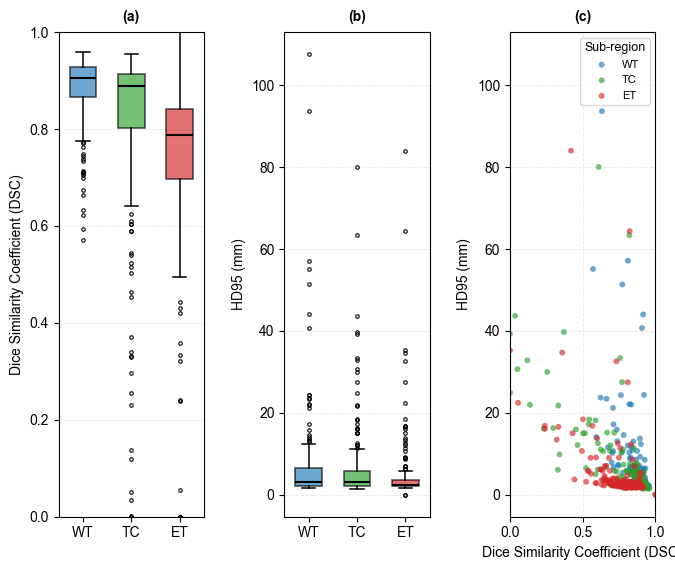


FIGURE 5 SAVED SUCCESSFULLY
PNG : C:\Users\eraze\saved\Fig5_Segmentation_Performance_Native_Space.png
PDF : C:\Users\eraze\saved\Fig5_Segmentation_Performance_Native_Space.pdf
PNG resolution : 600 dpi
Font           : Arial
Font size      : 10 pt
Internal title : REMOVED
Panels         : a, b, c
Output folder  : saved


In [3]:
# ============================================================
# FIGURE 5 — Segmentation performance by tumor sub-region
# Independent test cohort: N = 188
# Native acquisition space
# FINAL PUBLICATION VERSION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# 1. Create output folder
# ============================================================

output_dir = "saved"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# 2. Load FINAL native-space metrics
# ============================================================

csv_file = "Native_Space_Metrics_WT_TC_ET.csv"

df = pd.read_csv(csv_file)

# ============================================================
# 3. Required columns
# ============================================================

required_columns = [
    "Patient",
    "DSC_WT",
    "DSC_TC",
    "DSC_ET",
    "HD95_WT_mm",
    "HD95_TC_mm",
    "HD95_ET_mm"
]

missing = [col for col in required_columns if col not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

# ============================================================
# 4. Convert numeric columns
# ============================================================

for col in required_columns:
    if col != "Patient":
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["Patient"] = pd.to_numeric(
    df["Patient"],
    errors="coerce"
)

# Remove rows without patient ID
df = df[df["Patient"].notna()].copy()

df["Patient"] = df["Patient"].astype(int)

# ============================================================
# 5. Display final statistics
# ============================================================

print("=" * 75)
print("FIGURE 5 — FINAL NATIVE-SPACE STATISTICS")
print("=" * 75)

print(f"Number of patients: {len(df)}")

print("\nDSC:")
for region in ["WT", "TC", "ET"]:
    values = df[f"DSC_{region}"].dropna()

    print(
        f"{region}: "
        f"Mean = {values.mean():.4f}, "
        f"Median = {values.median():.4f}, "
        f"SD = {values.std(ddof=1):.4f}"
    )

print("\nHD95:")
for region in ["WT", "TC", "ET"]:
    values = df[f"HD95_{region}_mm"].dropna()

    print(
        f"{region}: "
        f"Mean = {values.mean():.4f} mm, "
        f"Median = {values.median():.4f} mm, "
        f"SD = {values.std(ddof=1):.4f} mm"
    )

# ============================================================
# 6. Publication font
# ============================================================

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 10

# ============================================================
# 7. Create composite Figure 5
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17.4 / 2.54, 5.8)
)

# ============================================================
# PANEL a — DSC BOXPLOTS
# ============================================================

dsc_data = [
    df["DSC_WT"].dropna(),
    df["DSC_TC"].dropna(),
    df["DSC_ET"].dropna()
]

box_a = axes[0].boxplot(
    dsc_data,
    labels=["WT", "TC", "ET"],
    patch_artist=True,
    widths=0.55,
    medianprops=dict(
        color="black",
        linewidth=1.5
    ),
    boxprops=dict(
        linewidth=1.2
    ),
    whiskerprops=dict(
        linewidth=1.1
    ),
    capprops=dict(
        linewidth=1.1
    ),
    flierprops=dict(
        marker="o",
        markersize=2.5,
        markerfacecolor="none",
        markeredgewidth=0.8
    )
)

# Different colors for WT / TC / ET
panel_a_colors = [
    "#1f77b4",
    "#2ca02c",
    "#d62728"
]

for patch, color in zip(
    box_a["boxes"],
    panel_a_colors
):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

axes[0].set_ylabel(
    "Dice Similarity Coefficient (DSC)",
    fontsize=10
)

axes[0].set_ylim(
    0,
    1.0
)

axes[0].set_title(
    "(a)",
    fontsize=10,
    fontweight="bold",
    pad=8
)

axes[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.25,
    linewidth=0.7
)

# ============================================================
# PANEL b — HD95 BOXPLOTS
# ============================================================

hd95_data = [
    df["HD95_WT_mm"].dropna(),
    df["HD95_TC_mm"].dropna(),
    df["HD95_ET_mm"].dropna()
]

box_b = axes[1].boxplot(
    hd95_data,
    labels=["WT", "TC", "ET"],
    patch_artist=True,
    widths=0.55,
    medianprops=dict(
        color="black",
        linewidth=1.5
    ),
    boxprops=dict(
        linewidth=1.2
    ),
    whiskerprops=dict(
        linewidth=1.1
    ),
    capprops=dict(
        linewidth=1.1
    ),
    flierprops=dict(
        marker="o",
        markersize=2.5,
        markerfacecolor="none",
        markeredgewidth=0.8
    )
)

panel_b_colors = [
    "#1f77b4",
    "#2ca02c",
    "#d62728"
]

for patch, color in zip(
    box_b["boxes"],
    panel_b_colors
):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

axes[1].set_ylabel(
    "HD95 (mm)",
    fontsize=10
)

axes[1].set_title(
    "(b)",
    fontsize=10,
    fontweight="bold",
    pad=8
)

axes[1].grid(
    axis="y",
    linestyle="--",
    alpha=0.25,
    linewidth=0.7
)

# ============================================================
# PANEL c — DSC vs HD95 SCATTER
# ============================================================

regions = {
    "WT": {
        "dsc": "DSC_WT",
        "hd95": "HD95_WT_mm",
        "color": "#1f77b4"
    },
    "TC": {
        "dsc": "DSC_TC",
        "hd95": "HD95_TC_mm",
        "color": "#2ca02c"
    },
    "ET": {
        "dsc": "DSC_ET",
        "hd95": "HD95_ET_mm",
        "color": "#d62728"
    }
}

for region, info in regions.items():

    valid = (
        df[info["dsc"]].notna()
        &
        df[info["hd95"]].notna()
    )

    axes[2].scatter(
        df.loc[valid, info["dsc"]],
        df.loc[valid, info["hd95"]],
        s=18,
        alpha=0.65,
        label=region,
        color=info["color"],
        edgecolors="none"
    )

axes[2].set_xlabel(
    "Dice Similarity Coefficient (DSC)",
    fontsize=10
)

axes[2].set_ylabel(
    "HD95 (mm)",
    fontsize=10
)

axes[2].set_xlim(
    0,
    1.0
)

axes[2].set_title(
    "(c)",
    fontsize=10,
    fontweight="bold",
    pad=8
)

axes[2].grid(
    True,
    linestyle="--",
    alpha=0.25,
    linewidth=0.7
)

axes[2].legend(
    title="Sub-region",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    loc="upper right"
)

# ============================================================
# 8. Final composite layout
# ============================================================

plt.tight_layout(
    w_pad=2.0
)

# ============================================================
# 9. Save Figure 5
# ============================================================

png_file = os.path.join(
    output_dir,
    "Fig5_Segmentation_Performance_Native_Space.png"
)

pdf_file = os.path.join(
    output_dir,
    "Fig5_Segmentation_Performance_Native_Space.pdf"
)

# ------------------------------------------------------------
# PNG — 600 dpi
# ------------------------------------------------------------

plt.savefig(
    png_file,
    dpi=600,
    bbox_inches="tight"
)

# ------------------------------------------------------------
# PDF — vector format
# ------------------------------------------------------------

plt.savefig(
    pdf_file,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 10. Confirmation
# ============================================================

print("\n" + "=" * 75)
print("FIGURE 5 SAVED SUCCESSFULLY")
print("=" * 75)

print(f"PNG : {os.path.abspath(png_file)}")
print(f"PDF : {os.path.abspath(pdf_file)}")
print("PNG resolution : 600 dpi")
print("Font           : Arial")
print("Font size      : 10 pt")
print("Internal title : REMOVED")
print("Panels         : a, b, c")
print("Output folder  : saved")
print("=" * 75)



PATIENT 75
Best Axial slice: 76


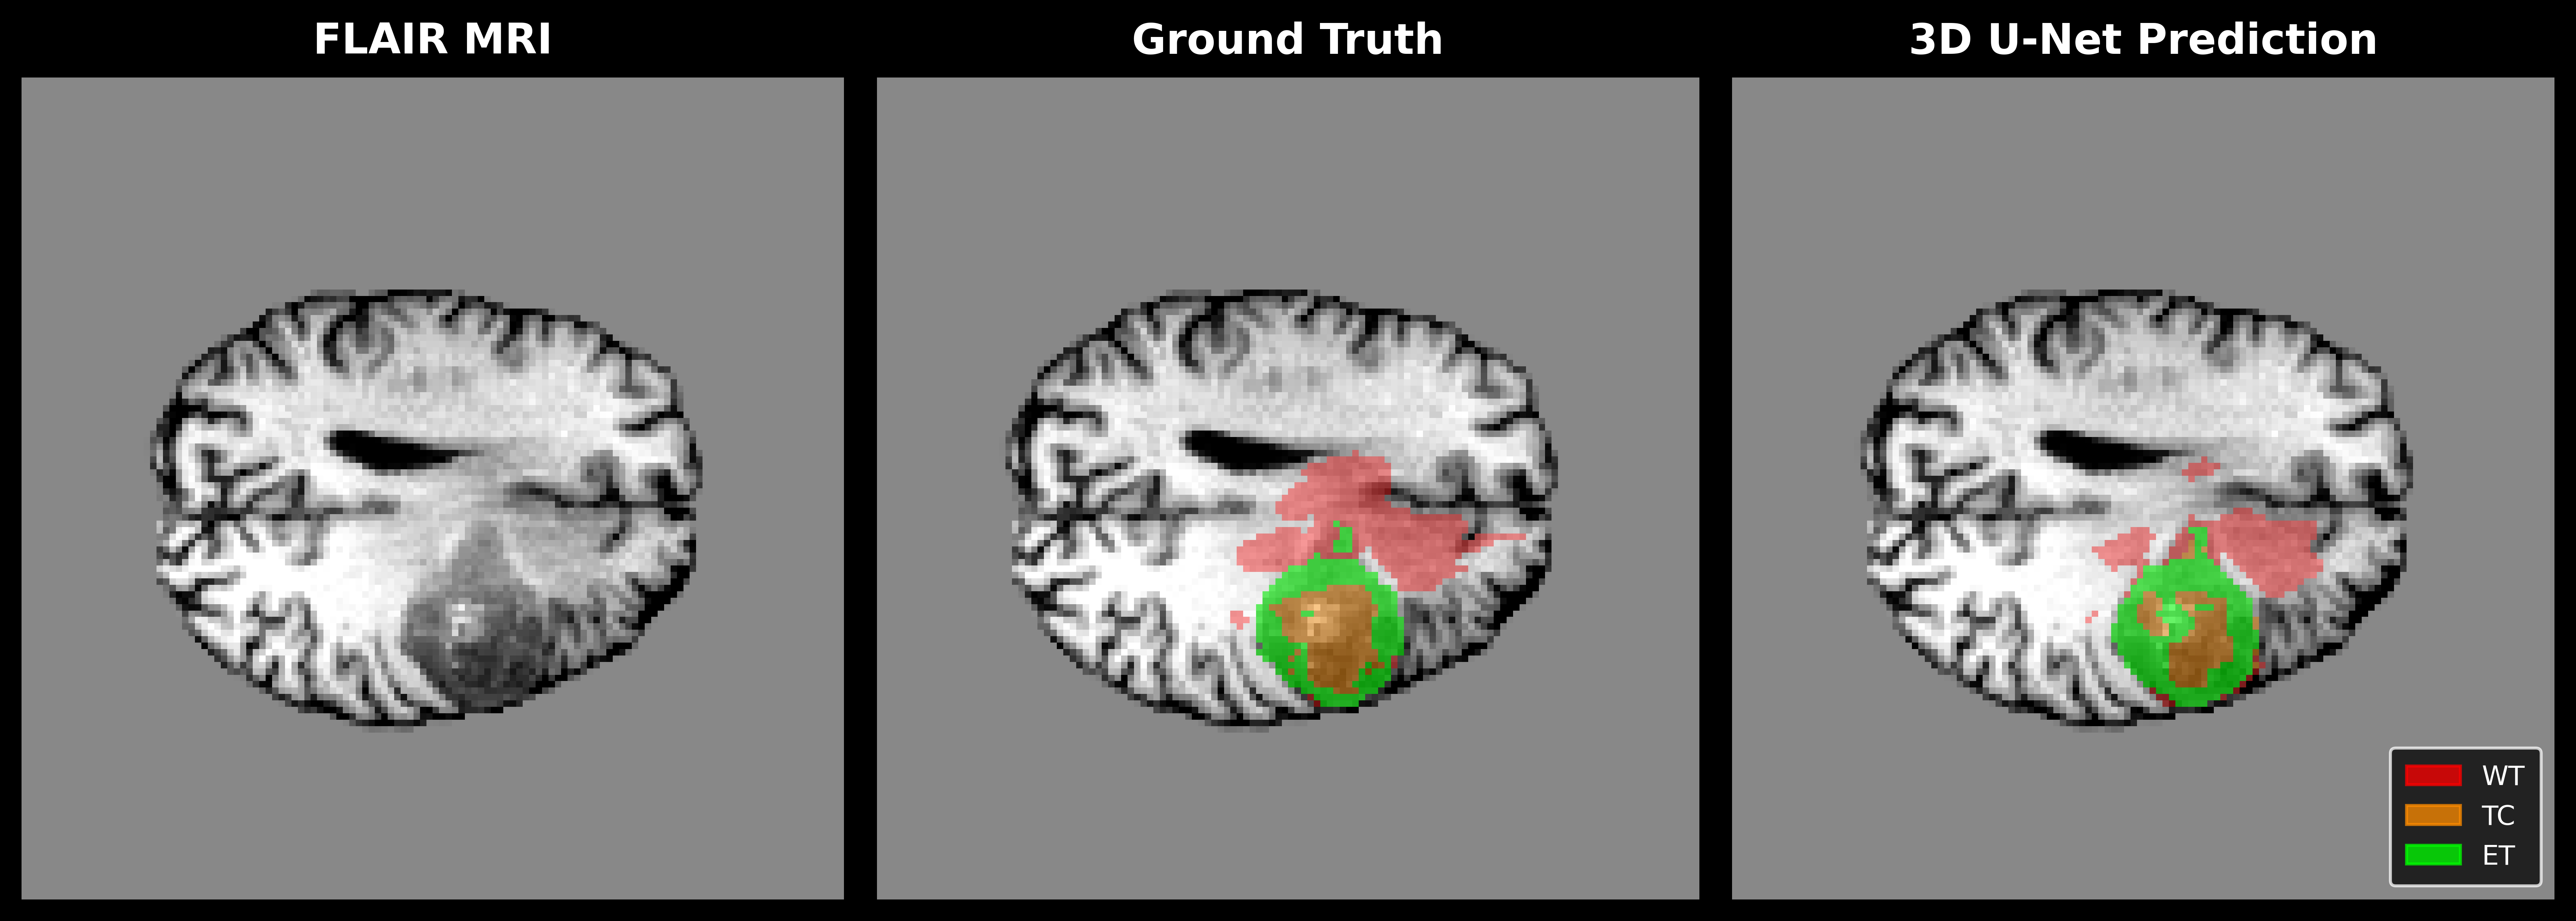

Saved: C:\Users\eraze\Saved\Patient_75_Axial_600dpi.png
Saved: C:\Users\eraze\Saved\Patient_75_Axial.pdf
Best Coronal slice: 72


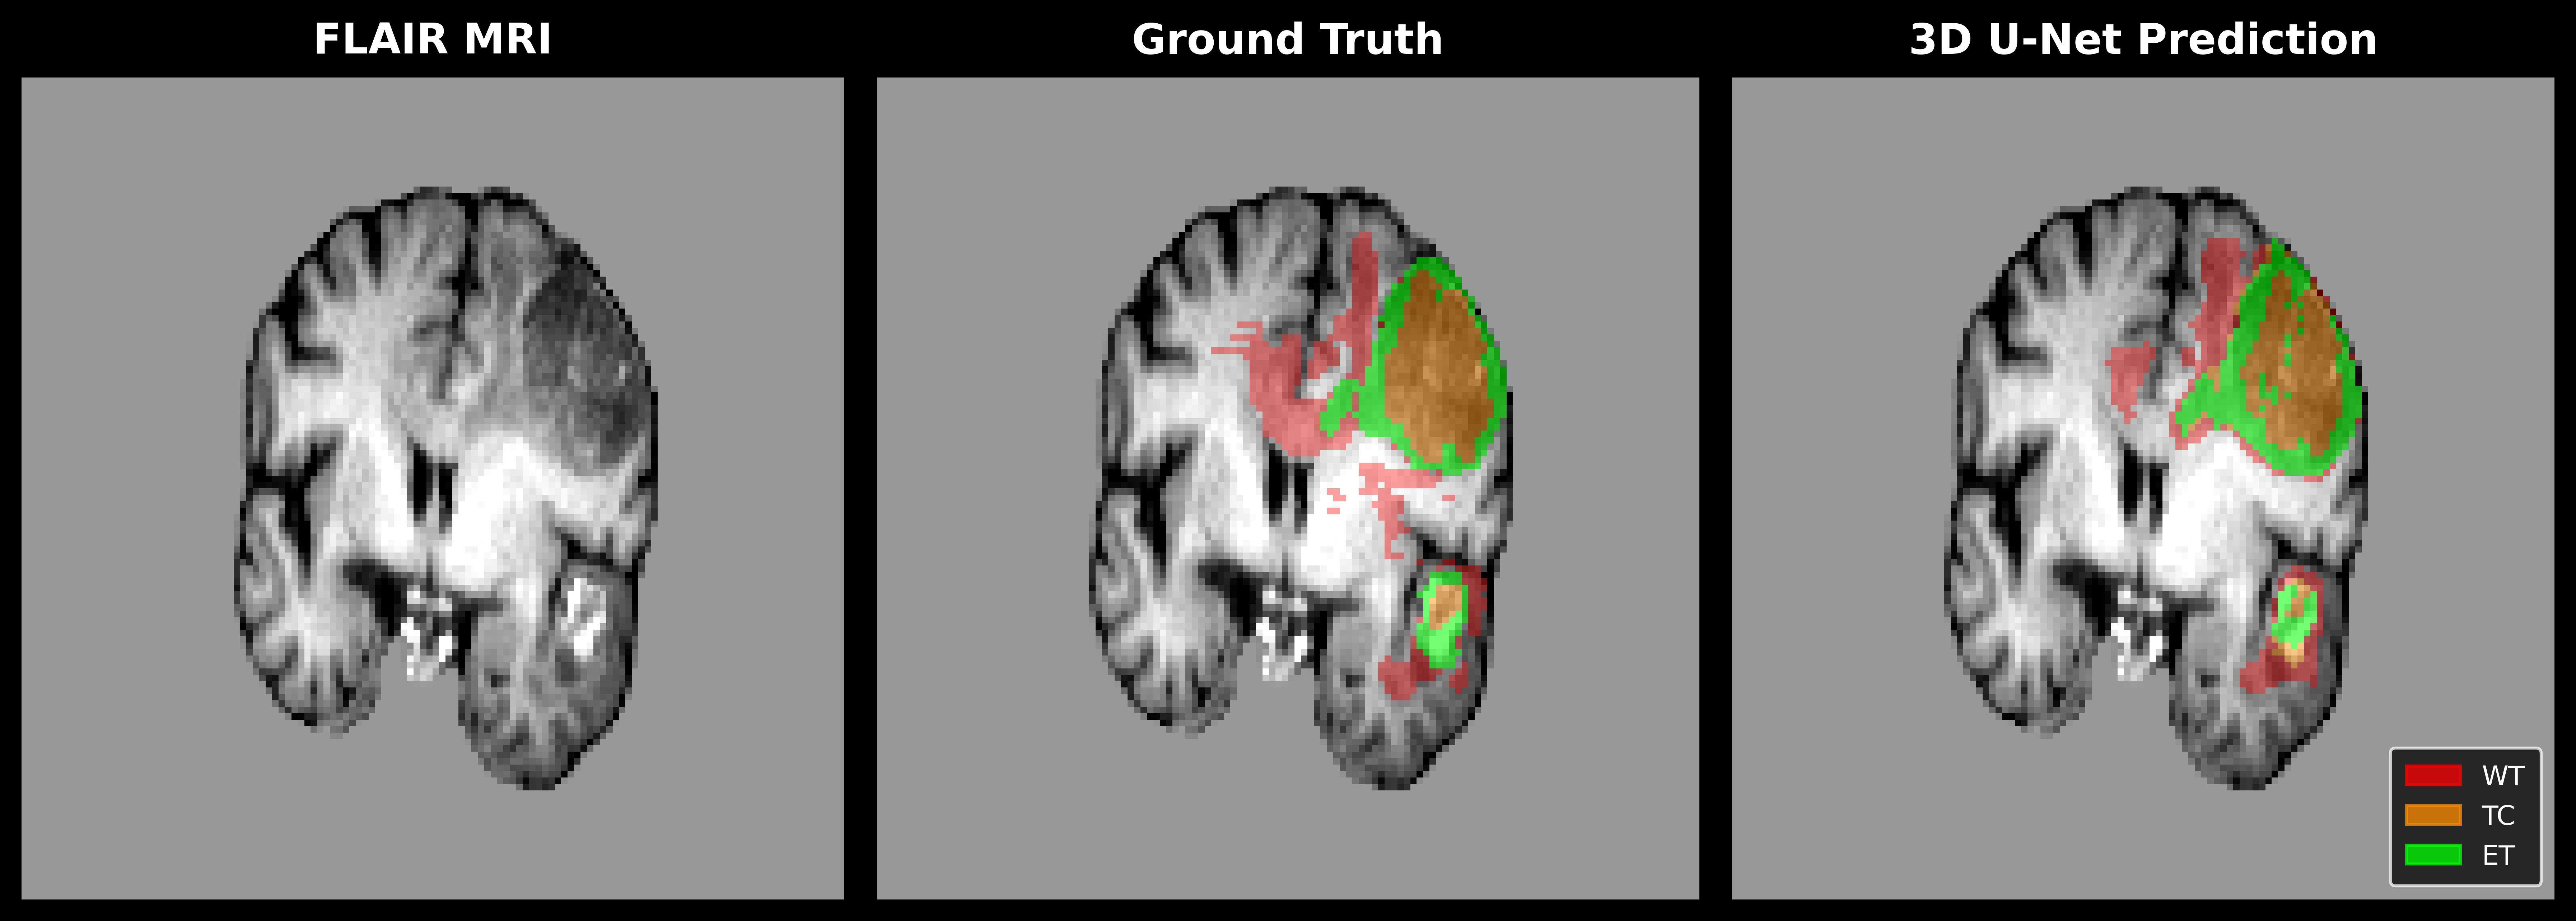

Saved: C:\Users\eraze\Saved\Patient_75_Coronal_600dpi.png
Saved: C:\Users\eraze\Saved\Patient_75_Coronal.pdf
Best Sagittal slice: 76


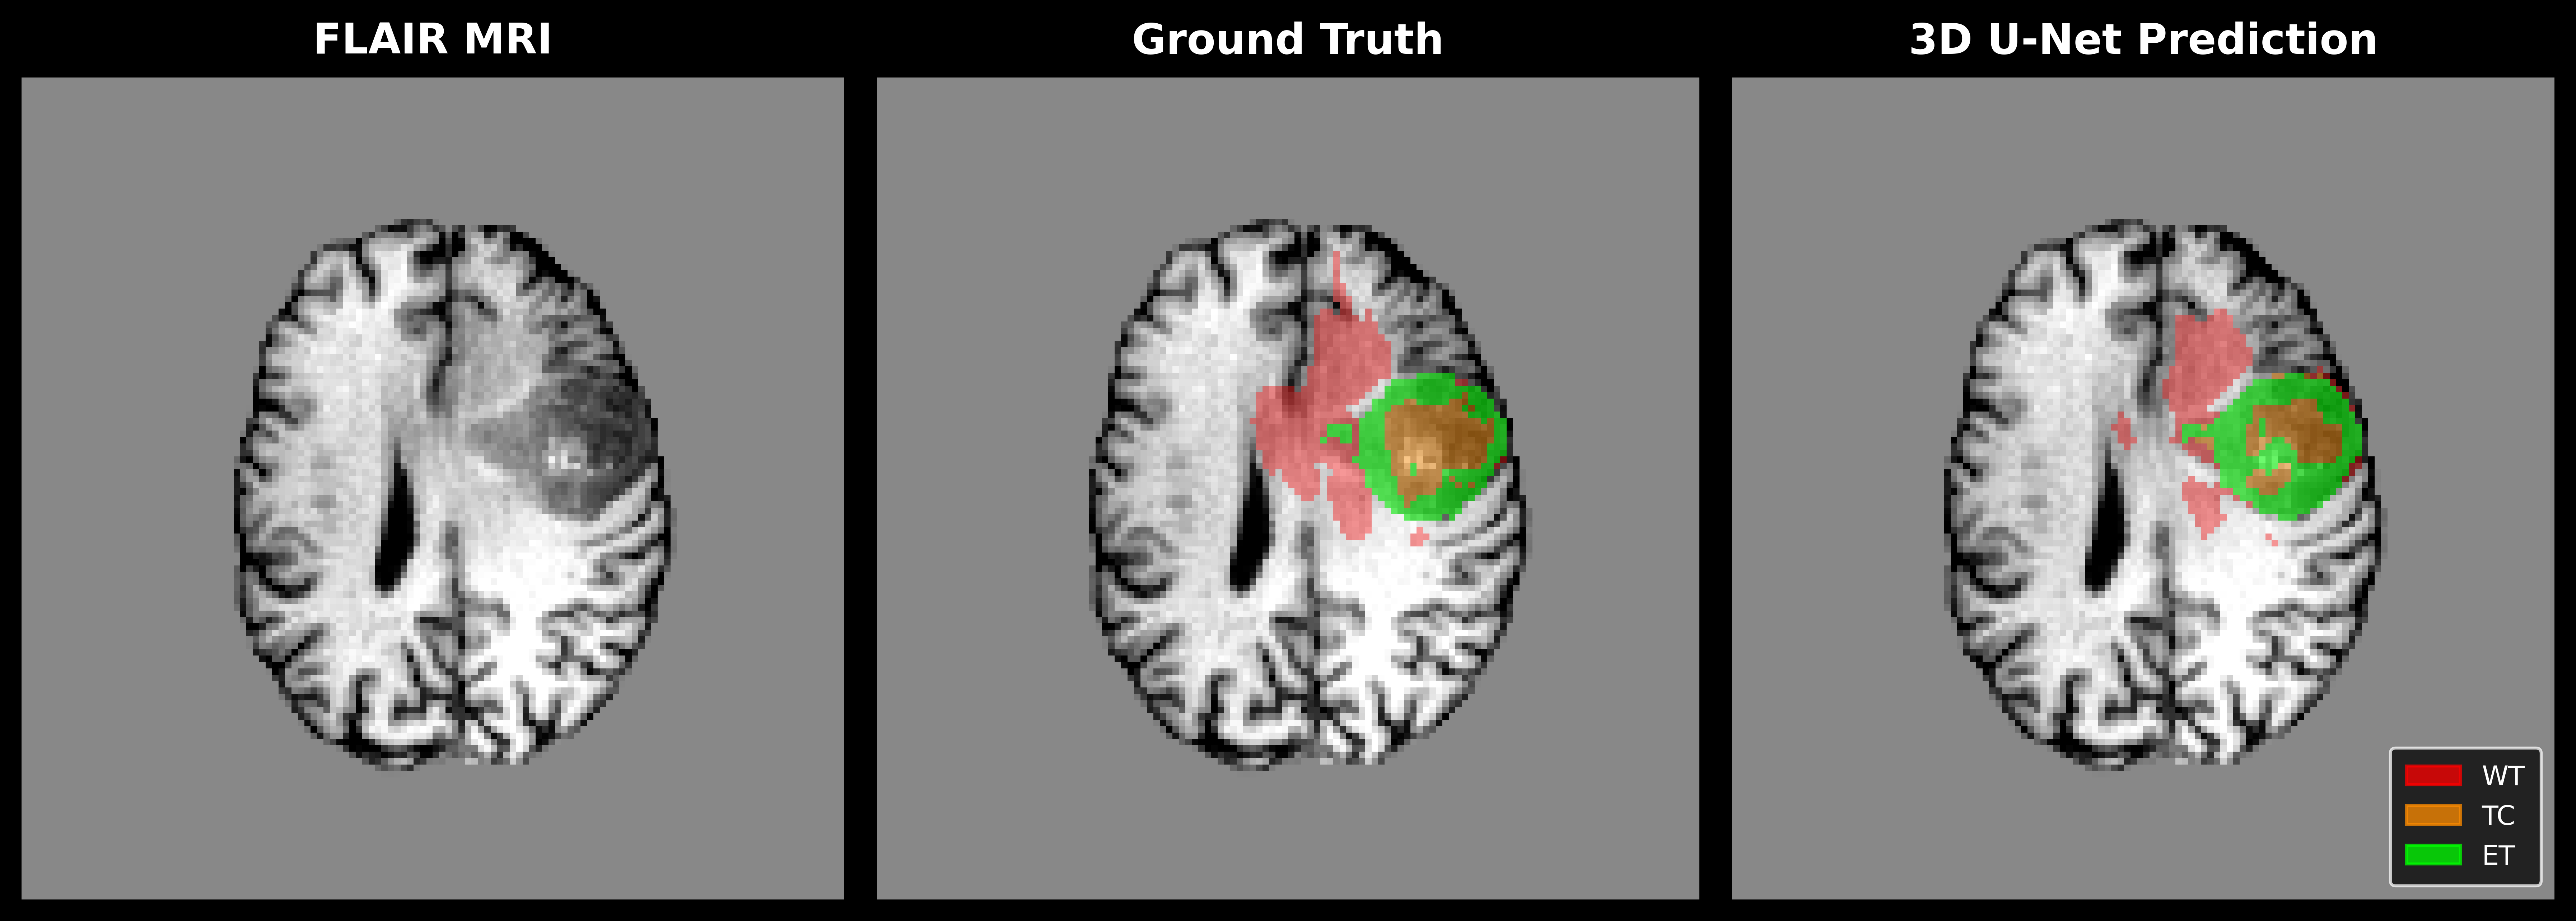

Saved: C:\Users\eraze\Saved\Patient_75_Sagittal_600dpi.png
Saved: C:\Users\eraze\Saved\Patient_75_Sagittal.pdf


PATIENT 53
Best Axial slice: 43


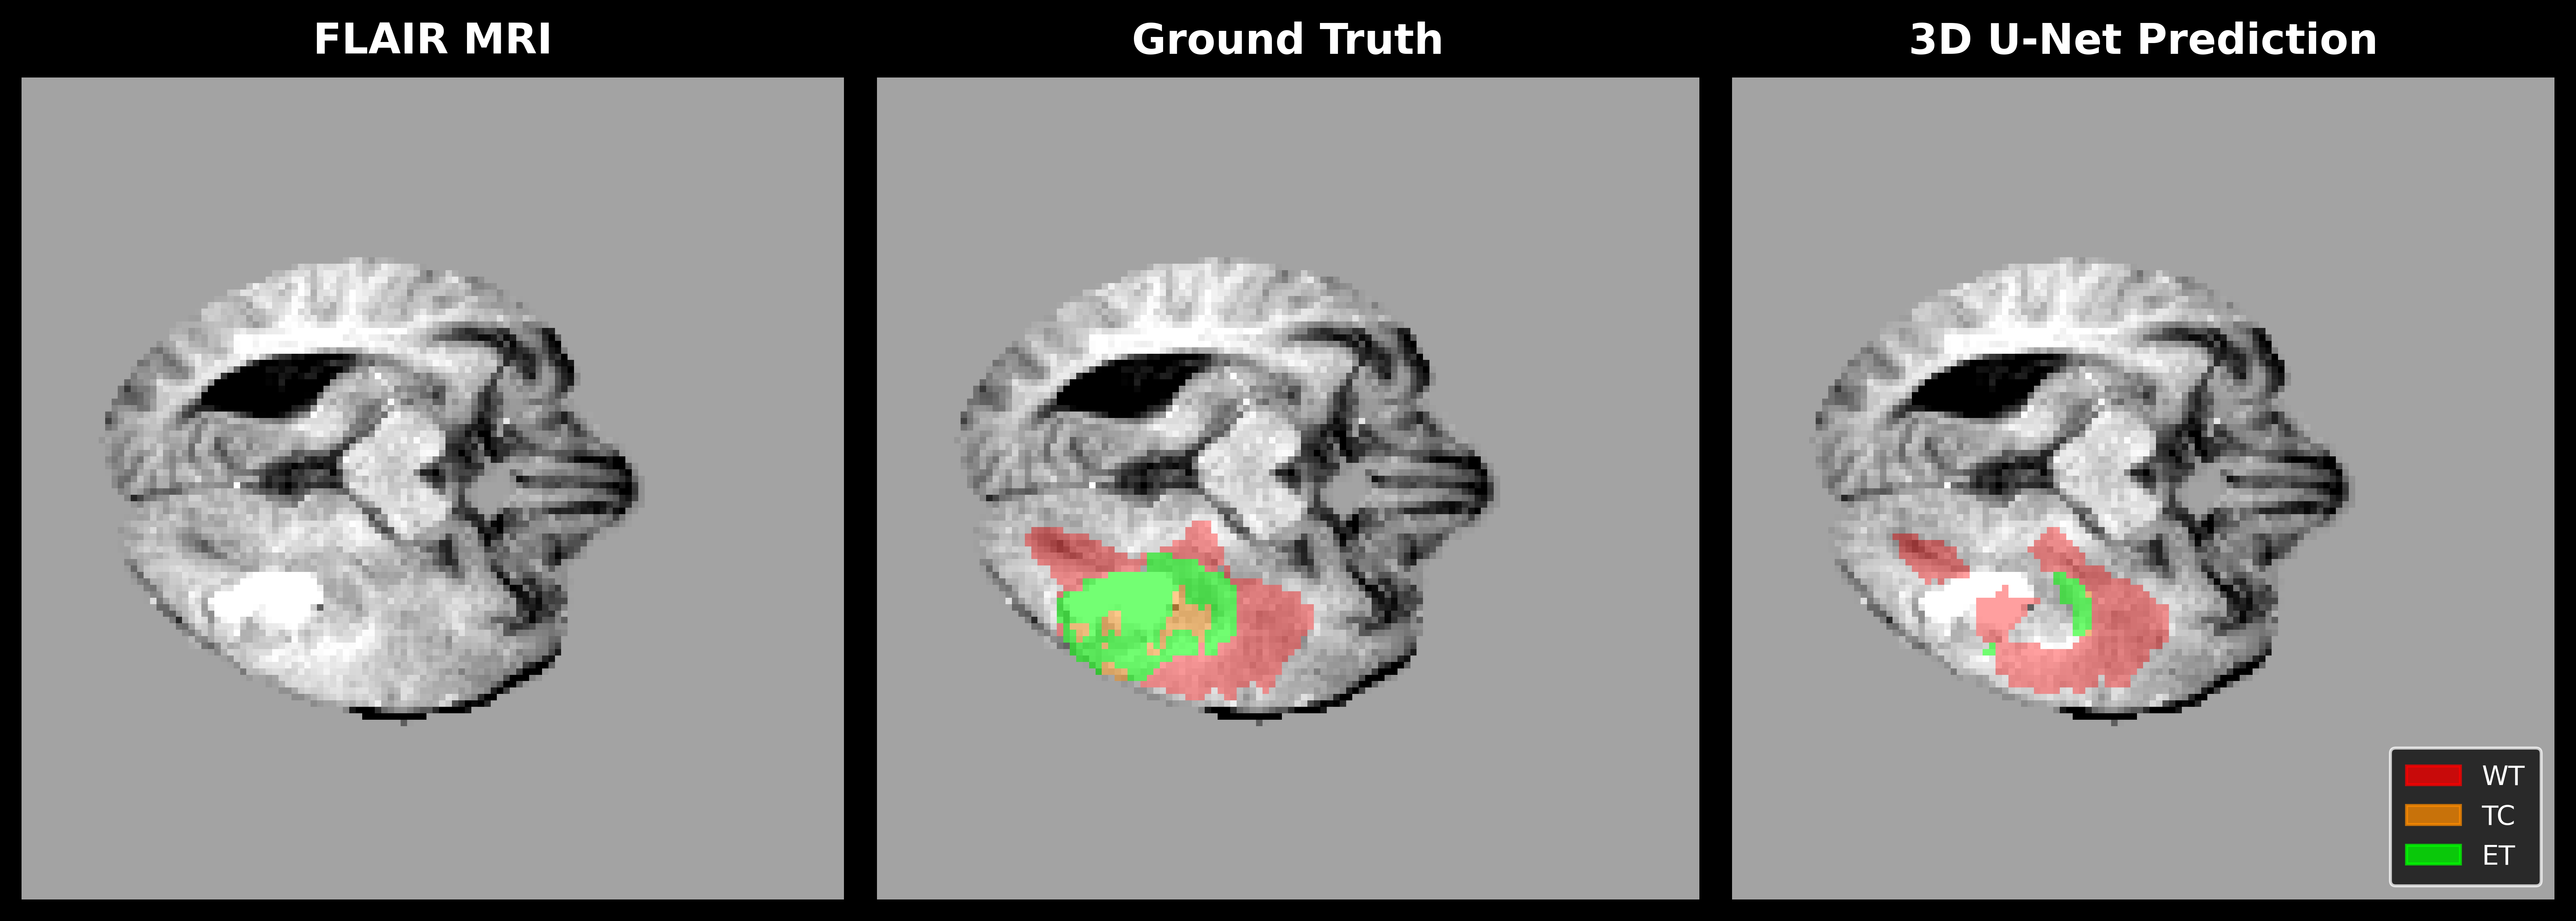

Saved: C:\Users\eraze\Saved\Patient_53_Axial_600dpi.png
Saved: C:\Users\eraze\Saved\Patient_53_Axial.pdf
Best Coronal slice: 39


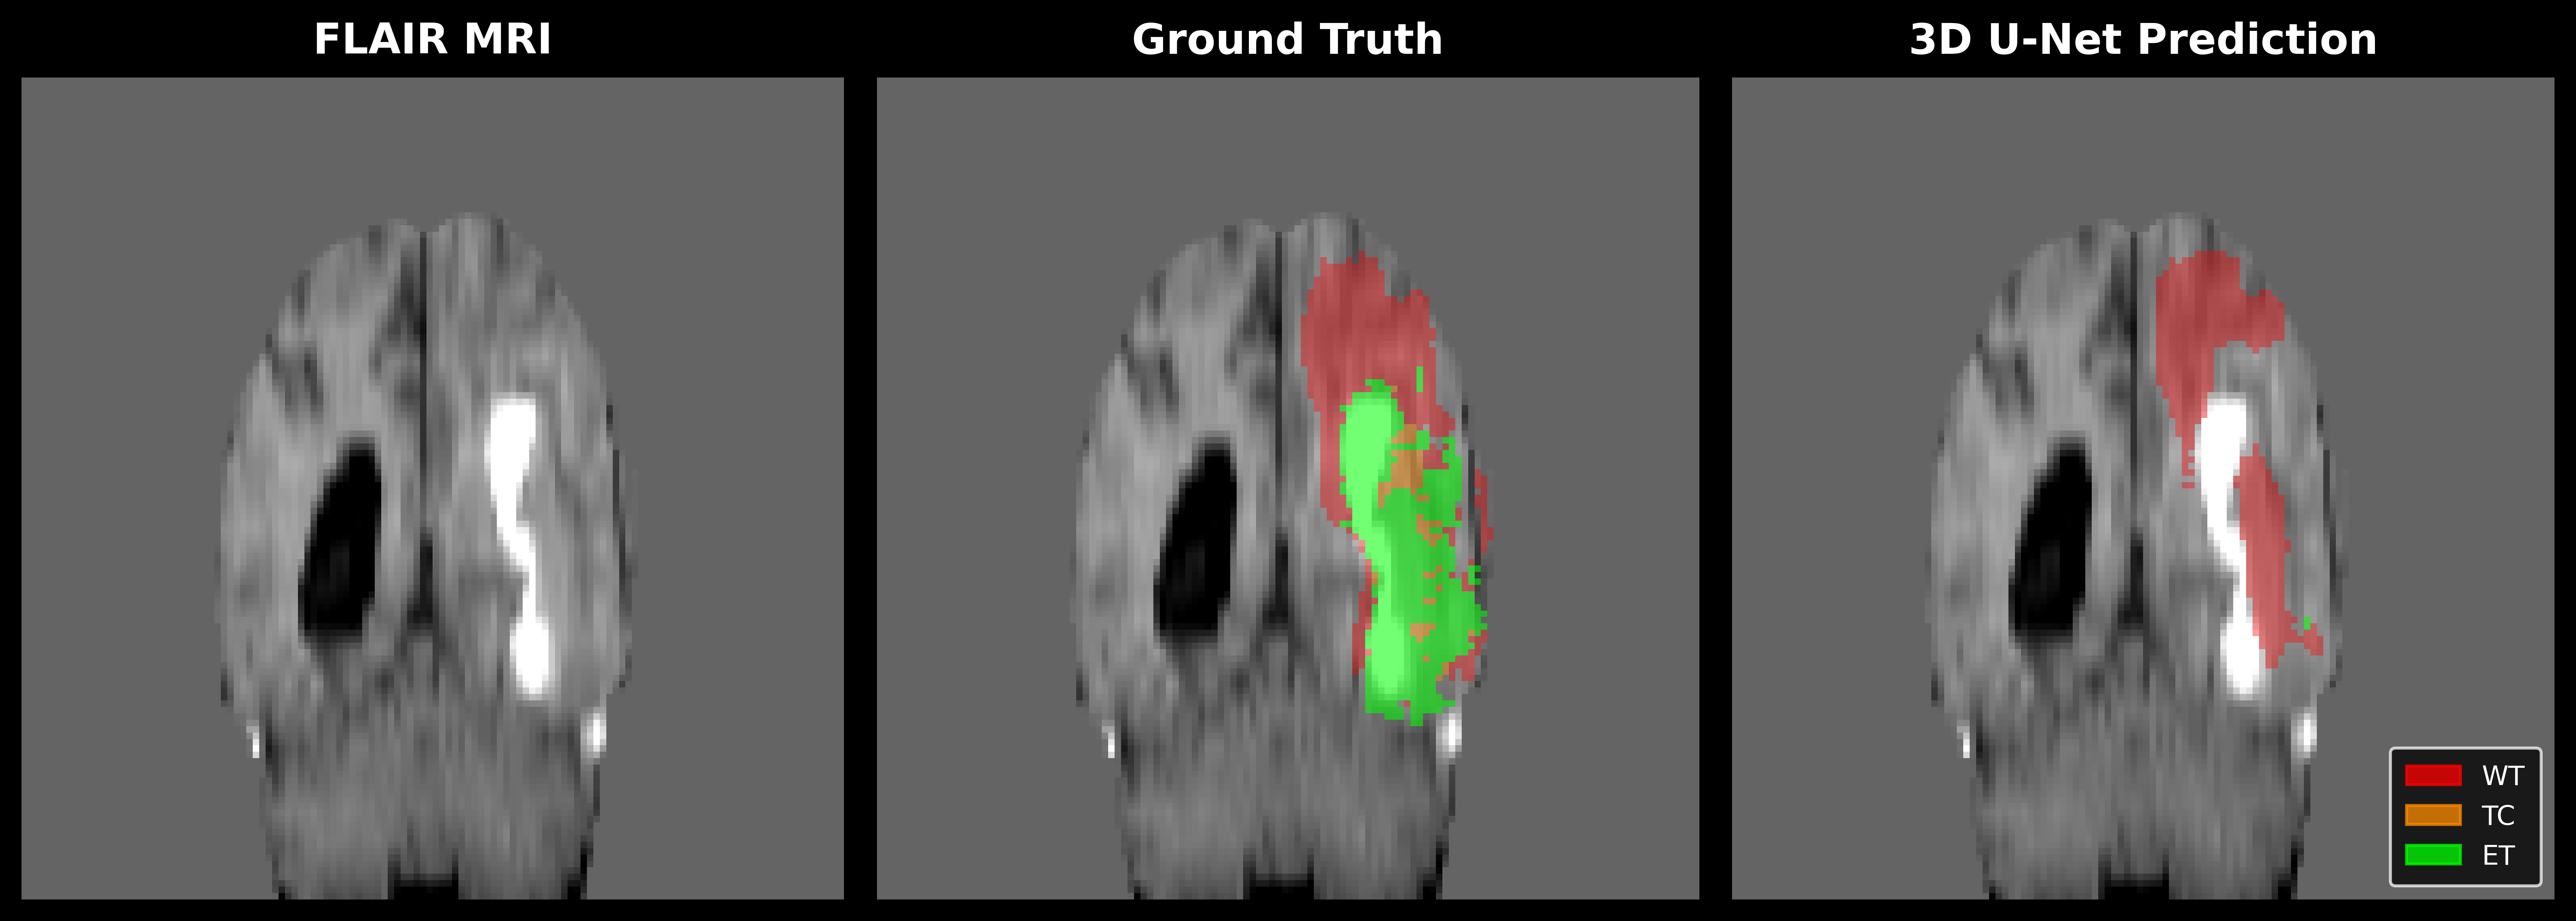

Saved: C:\Users\eraze\Saved\Patient_53_Coronal_600dpi.png
Saved: C:\Users\eraze\Saved\Patient_53_Coronal.pdf
Best Sagittal slice: 43


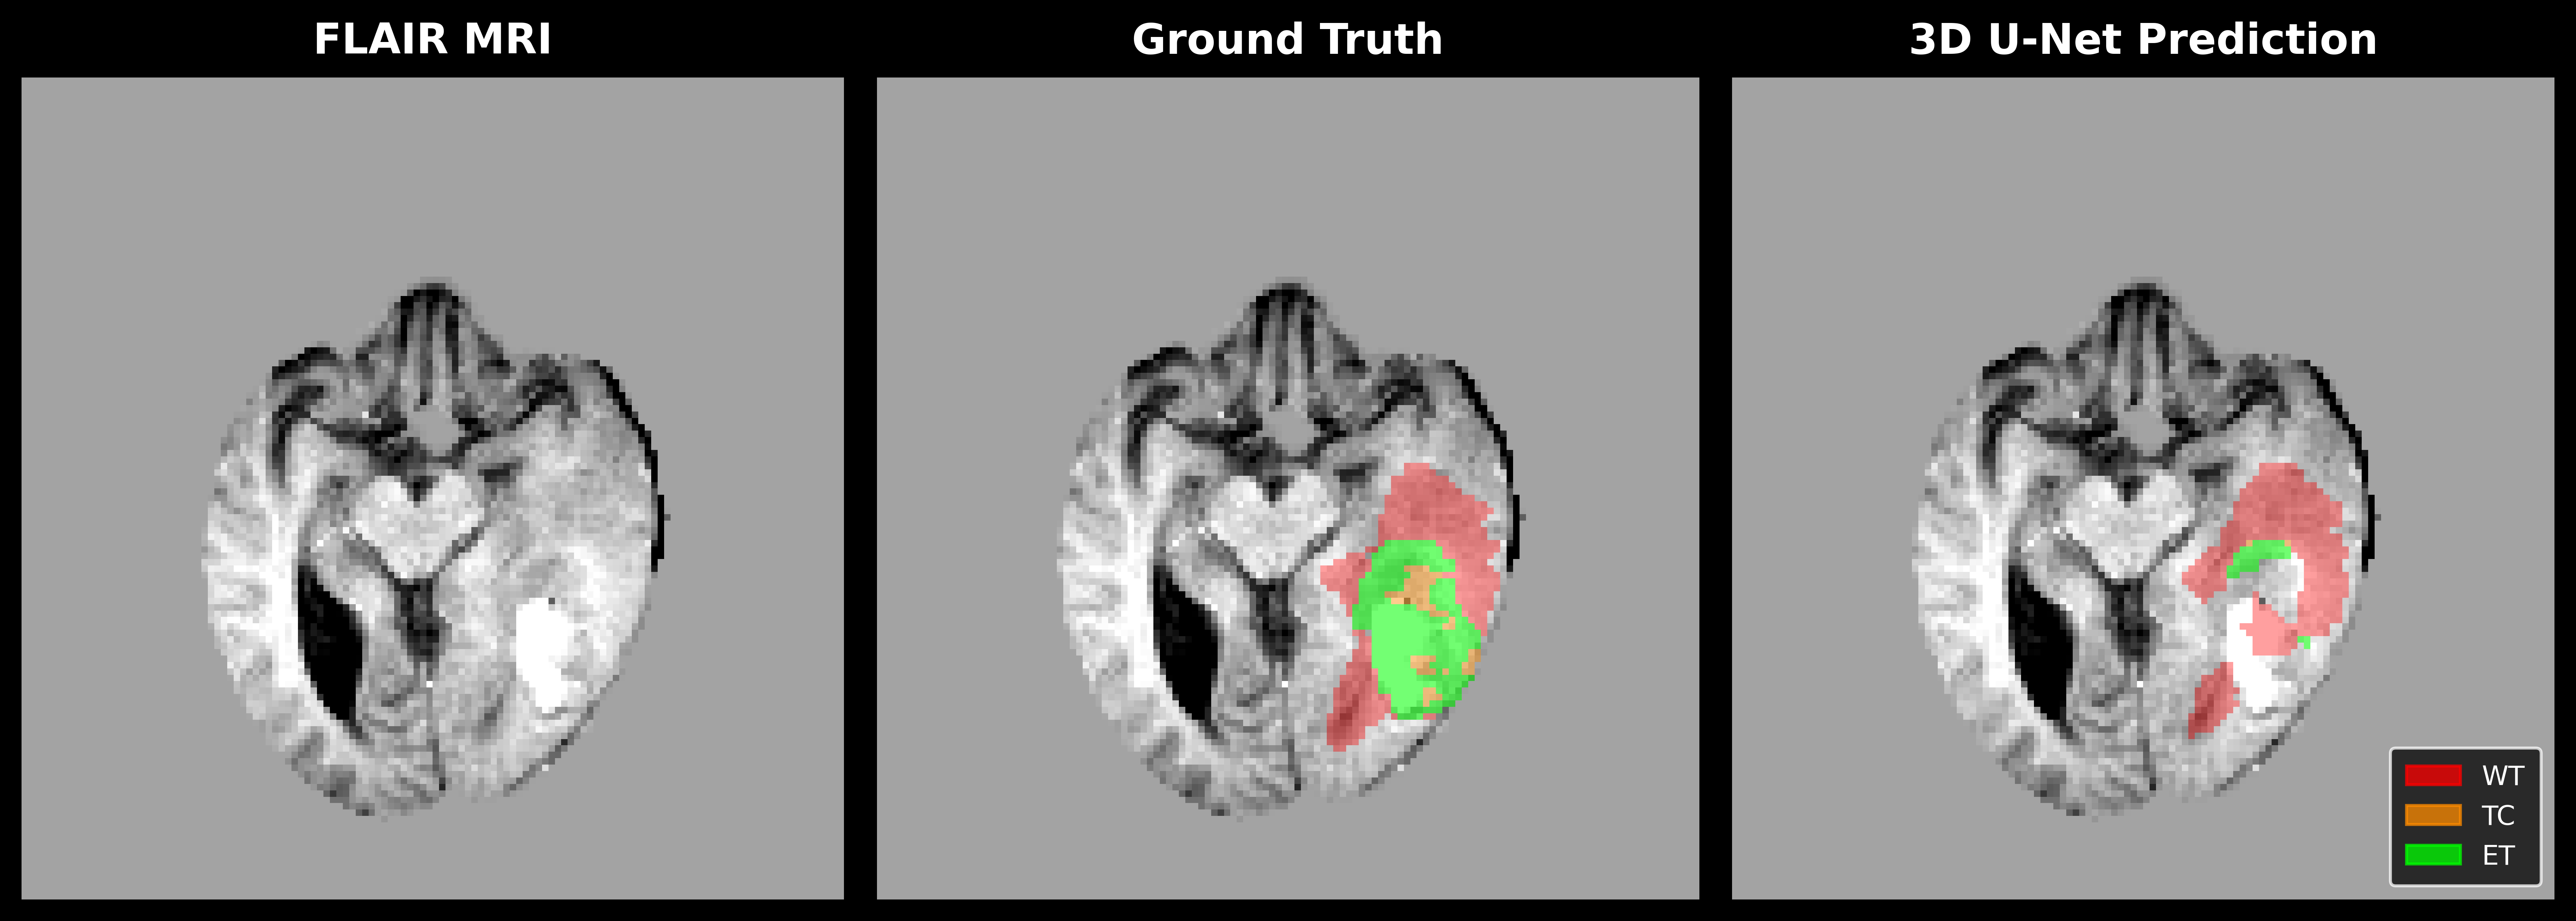

Saved: C:\Users\eraze\Saved\Patient_53_Sagittal_600dpi.png
Saved: C:\Users\eraze\Saved\Patient_53_Sagittal.pdf


ALL FIGURES COMPLETED

Patient 75:
  Saved/Patient_75_Axial_600dpi.png
  Saved/Patient_75_Axial.pdf
  Saved/Patient_75_Coronal_600dpi.png
  Saved/Patient_75_Coronal.pdf
  Saved/Patient_75_Sagittal_600dpi.png
  Saved/Patient_75_Sagittal.pdf

Patient 53:
  Saved/Patient_53_Axial_600dpi.png
  Saved/Patient_53_Axial.pdf
  Saved/Patient_53_Coronal_600dpi.png
  Saved/Patient_53_Coronal.pdf
  Saved/Patient_53_Sagittal_600dpi.png
  Saved/Patient_53_Sagittal.pdf



In [84]:
# ============================================================
# PUBLICATION-QUALITY FIGURES
# PATIENTS 75 & 53
# AXIAL + CORONAL + SAGITTAL
#
# 600 DPI
# NO PATIENT / DSC / HD95 HEADER
# ============================================================

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# ============================================================
# 1. OUTPUT DIRECTORY
# ============================================================

os.makedirs("Saved", exist_ok=True)

# ============================================================
# 2. PATIENTS TO DISPLAY
# ============================================================

patient_numbers = [75, 53]

# ============================================================
# 3. PUBLICATION COLORS
# ============================================================

mask_cmap = ListedColormap([
    (0.0, 0.0, 0.0, 0.0),    # Background
    (1.0, 0.0, 0.0, 0.38),    # WT
    (1.0, 0.55, 0.0, 0.45),   # TC
    (0.0, 1.0, 0.0, 0.55)     # ET
])

# ============================================================
# 4. LEGEND
# ============================================================

legend_elements = [

    Patch(
        facecolor="#FF0000",
        edgecolor="#FF0000",
        alpha=0.75,
        label="WT"
    ),

    Patch(
        facecolor="#FF8C00",
        edgecolor="#FF8C00",
        alpha=0.75,
        label="TC"
    ),

    Patch(
        facecolor="#00FF00",
        edgecolor="#00FF00",
        alpha=0.75,
        label="ET"
    )
]

# ============================================================
# 5. CONVERT BRATS MULTI-CHANNEL MASK
#    INTO ONE LABEL MAP
#
#    0 = Background
#    1 = WT
#    2 = TC
#    3 = ET
# ============================================================

def make_label_map(mask, spatial_shape):

    label_map = np.zeros(
        spatial_shape,
        dtype=np.uint8
    )

    # --------------------------------------------------------
    # ET
    # --------------------------------------------------------

    if mask.shape[0] >= 3:

        label_map[
            mask[2] > 0
        ] = 3

    # --------------------------------------------------------
    # TC
    # --------------------------------------------------------

    if mask.shape[0] >= 2:

        tc_mask = mask[1] > 0

        label_map[
            tc_mask & (label_map == 0)
        ] = 2

    # --------------------------------------------------------
    # WT
    # --------------------------------------------------------

    if mask.shape[0] >= 1:

        wt_mask = mask[0] > 0

        label_map[
            wt_mask & (label_map == 0)
        ] = 1

    return label_map


# ============================================================
# 6. AUTOMATIC BRAIN CROP
# ============================================================

def crop_brain(
    flair_view,
    gt_view,
    pred_view
):

    brain_mask = (
        flair_view >
        flair_view.max() * 0.02
    )

    ys, xs = np.where(
        brain_mask
    )

    if len(xs) == 0:

        return (
            flair_view,
            gt_view,
            pred_view
        )

    x_min = xs.min()
    x_max = xs.max()

    y_min = ys.min()
    y_max = ys.max()

    # Small margin
    margin = 4

    x_min = max(
        0,
        x_min - margin
    )

    x_max = min(
        flair_view.shape[1] - 1,
        x_max + margin
    )

    y_min = max(
        0,
        y_min - margin
    )

    y_max = min(
        flair_view.shape[0] - 1,
        y_max + margin
    )

    return (

        flair_view[
            y_min:y_max + 1,
            x_min:x_max + 1
        ],

        gt_view[
            y_min:y_max + 1,
            x_min:x_max + 1
        ],

        pred_view[
            y_min:y_max + 1,
            x_min:x_max + 1
        ]
    )


# ============================================================
# 7. CREATE ONE VIEW
#
#    IMPORTANT:
#    NO PATIENT NAME
#    NO DSC
#    NO HD95
# ============================================================

def create_view(
    flair_view,
    gt_view,
    pred_view,
    plane_name,
    patient_number
):

    # --------------------------------------------------------
    # Crop only empty background
    # --------------------------------------------------------

    (
        flair_view,
        gt_view,
        pred_view
    ) = crop_brain(
        flair_view,
        gt_view,
        pred_view
    )

    # --------------------------------------------------------
    # MRI intensity
    # --------------------------------------------------------

    vmin = np.percentile(
        flair_view,
        1
    )

    vmax = np.percentile(
        flair_view,
        99
    )

    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(12.0, 4.7),
        dpi=600,
        facecolor="black"
    )

    for ax in axes:
        ax.set_facecolor("black")

    H, W = flair_view.shape

    extent = [
        0,
        W,
        H,
        0
    ]

    # ========================================================
    # FLAIR
    # ========================================================

    axes[0].imshow(
        flair_view,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        extent=extent,
        aspect="equal"
    )

    axes[0].set_title(
        "FLAIR MRI",
        color="white",
        fontsize=14,
        fontweight="bold",
        pad=8
    )

    # ========================================================
    # GROUND TRUTH
    # ========================================================

    axes[1].imshow(
        flair_view,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        extent=extent,
        aspect="equal"
    )

    axes[1].imshow(
        gt_view,
        cmap=mask_cmap,
        vmin=0,
        vmax=3,
        interpolation="nearest",
        extent=extent,
        aspect="equal"
    )

    axes[1].set_title(
        "Ground Truth",
        color="white",
        fontsize=14,
        fontweight="bold",
        pad=8
    )

    # ========================================================
    # PREDICTION
    # ========================================================

    axes[2].imshow(
        flair_view,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        extent=extent,
        aspect="equal"
    )

    axes[2].imshow(
        pred_view,
        cmap=mask_cmap,
        vmin=0,
        vmax=3,
        interpolation="nearest",
        extent=extent,
        aspect="equal"
    )

    axes[2].set_title(
        "3D U-Net Prediction",
        color="white",
        fontsize=14,
        fontweight="bold",
        pad=8
    )

    # ========================================================
    # KEEP BRAIN PROPORTIONS
    # ========================================================

    for ax in axes:

        ax.set_xlim(
            0,
            W
        )

        ax.set_ylim(
            H,
            0
        )

        ax.set_aspect(
            "equal",
            adjustable="box"
        )

        ax.axis("off")

    # ========================================================
    # LEGEND
    # ========================================================

    legend = axes[2].legend(
        handles=legend_elements,
        loc="lower right",
        fontsize=9,
        frameon=True,
        facecolor="black",
        edgecolor="white",
        framealpha=0.75,
        borderpad=0.6
    )

    for text in legend.get_texts():
        text.set_color("white")

    # ========================================================
    # IMPORTANT:
    # NO GLOBAL TITLE
    # NO PATIENT NUMBER
    # NO DSC
    # NO HD95
    # ========================================================

    # ========================================================
    # LAYOUT
    # ========================================================

    plt.subplots_adjust(
        left=0.01,
        right=0.99,
        top=0.99,
        bottom=0.01,
        wspace=0.04
    )

    # ========================================================
    # SAVE
    # ========================================================

    png_path = (
        f"Saved/"
        f"Patient_{patient_number}_"
        f"{plane_name}_600dpi.png"
    )

    pdf_path = (
        f"Saved/"
        f"Patient_{patient_number}_"
        f"{plane_name}.pdf"
    )

    plt.savefig(
        png_path,
        dpi=600,
        bbox_inches="tight",
        facecolor="black",
        pad_inches=0.02
    )

    plt.savefig(
        pdf_path,
        bbox_inches="tight",
        facecolor="black",
        pad_inches=0.02
    )

    plt.show()

    print(
        f"Saved: {os.path.abspath(png_path)}"
    )

    print(
        f"Saved: {os.path.abspath(pdf_path)}"
    )


# ============================================================
# 8. PROCESS PATIENTS
# ============================================================

model.eval()

for patient_number in patient_numbers:

    print("\n")
    print("============================================")
    print(f"PATIENT {patient_number}")
    print("============================================")

    # --------------------------------------------------------
    # Load patient
    # --------------------------------------------------------

    sample = test_loader.dataset[
        patient_number - 1
    ]

    image = (
        sample["image"]
        .unsqueeze(0)
        .to(device)
    )

    label = (
        sample["label"]
        .unsqueeze(0)
        .to(device)
    )

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    with torch.no_grad():

        output = model(image)

    prediction = (
        torch.sigmoid(output) > 0.5
    ).float()

    pred_np = (
        prediction[0]
        .cpu()
        .numpy()
    )

    gt_np = (
        label[0]
        .cpu()
        .numpy()
    )

    # --------------------------------------------------------
    # FLAIR
    # --------------------------------------------------------

    flair = (
        image[0, 0]
        .detach()
        .cpu()
        .numpy()
    )

    flair = (
        flair - flair.min()
    ) / (
        flair.max() - flair.min() + 1e-8
    )

    # --------------------------------------------------------
    # Label maps
    # --------------------------------------------------------

    gt_label = make_label_map(
        gt_np,
        flair.shape
    )

    pred_label = make_label_map(
        pred_np,
        flair.shape
    )

    # --------------------------------------------------------
    # Combined mask
    # --------------------------------------------------------

    combined = np.maximum(
        gt_label,
        pred_label
    )

    # ========================================================
    # AXIAL
    # ========================================================

    axial_score = combined.sum(
        axis=(0, 1)
    )

    z = int(
        np.argmax(axial_score)
    )

    print(
        f"Best Axial slice: {z}"
    )

    flair_axial = flair[:, :, z]
    gt_axial = gt_label[:, :, z]
    pred_axial = pred_label[:, :, z]

    create_view(
        flair_axial,
        gt_axial,
        pred_axial,
        "Axial",
        patient_number
    )

    # ========================================================
    # CORONAL
    # ========================================================

    coronal_score = combined.sum(
        axis=(0, 2)
    )

    y = int(
        np.argmax(coronal_score)
    )

    print(
        f"Best Coronal slice: {y}"
    )

    flair_coronal = flair[:, y, :]
    gt_coronal = gt_label[:, y, :]
    pred_coronal = pred_label[:, y, :]

    # Rotate for anatomical display
    flair_coronal = np.rot90(
        flair_coronal
    )

    gt_coronal = np.rot90(
        gt_coronal
    )

    pred_coronal = np.rot90(
        pred_coronal
    )

    create_view(
        flair_coronal,
        gt_coronal,
        pred_coronal,
        "Coronal",
        patient_number
    )

    # ========================================================
    # SAGITTAL
    # ========================================================

    sagittal_score = combined.sum(
        axis=(0, 1)
    )

    x = int(
        np.argmax(sagittal_score)
    )

    print(
        f"Best Sagittal slice: {x}"
    )

    flair_sagittal = flair[:, :, x]
    gt_sagittal = gt_label[:, :, x]
    pred_sagittal = pred_label[:, :, x]

    # Rotate for anatomical display
    flair_sagittal = np.rot90(
        flair_sagittal
    )

    gt_sagittal = np.rot90(
        gt_sagittal
    )

    pred_sagittal = np.rot90(
        pred_sagittal
    )

    create_view(
        flair_sagittal,
        gt_sagittal,
        pred_sagittal,
        "Sagittal",
        patient_number
    )


# ============================================================
# 9. FINAL OUTPUT
# ============================================================

print("\n")
print("============================================")
print("ALL FIGURES COMPLETED")
print("============================================")

print("""
Patient 75:
  Saved/Patient_75_Axial_600dpi.png
  Saved/Patient_75_Axial.pdf
  Saved/Patient_75_Coronal_600dpi.png
  Saved/Patient_75_Coronal.pdf
  Saved/Patient_75_Sagittal_600dpi.png
  Saved/Patient_75_Sagittal.pdf

Patient 53:
  Saved/Patient_53_Axial_600dpi.png
  Saved/Patient_53_Axial.pdf
  Saved/Patient_53_Coronal_600dpi.png
  Saved/Patient_53_Coronal.pdf
  Saved/Patient_53_Sagittal_600dpi.png
  Saved/Patient_53_Sagittal.pdf
""")

Best Axial slice: 60


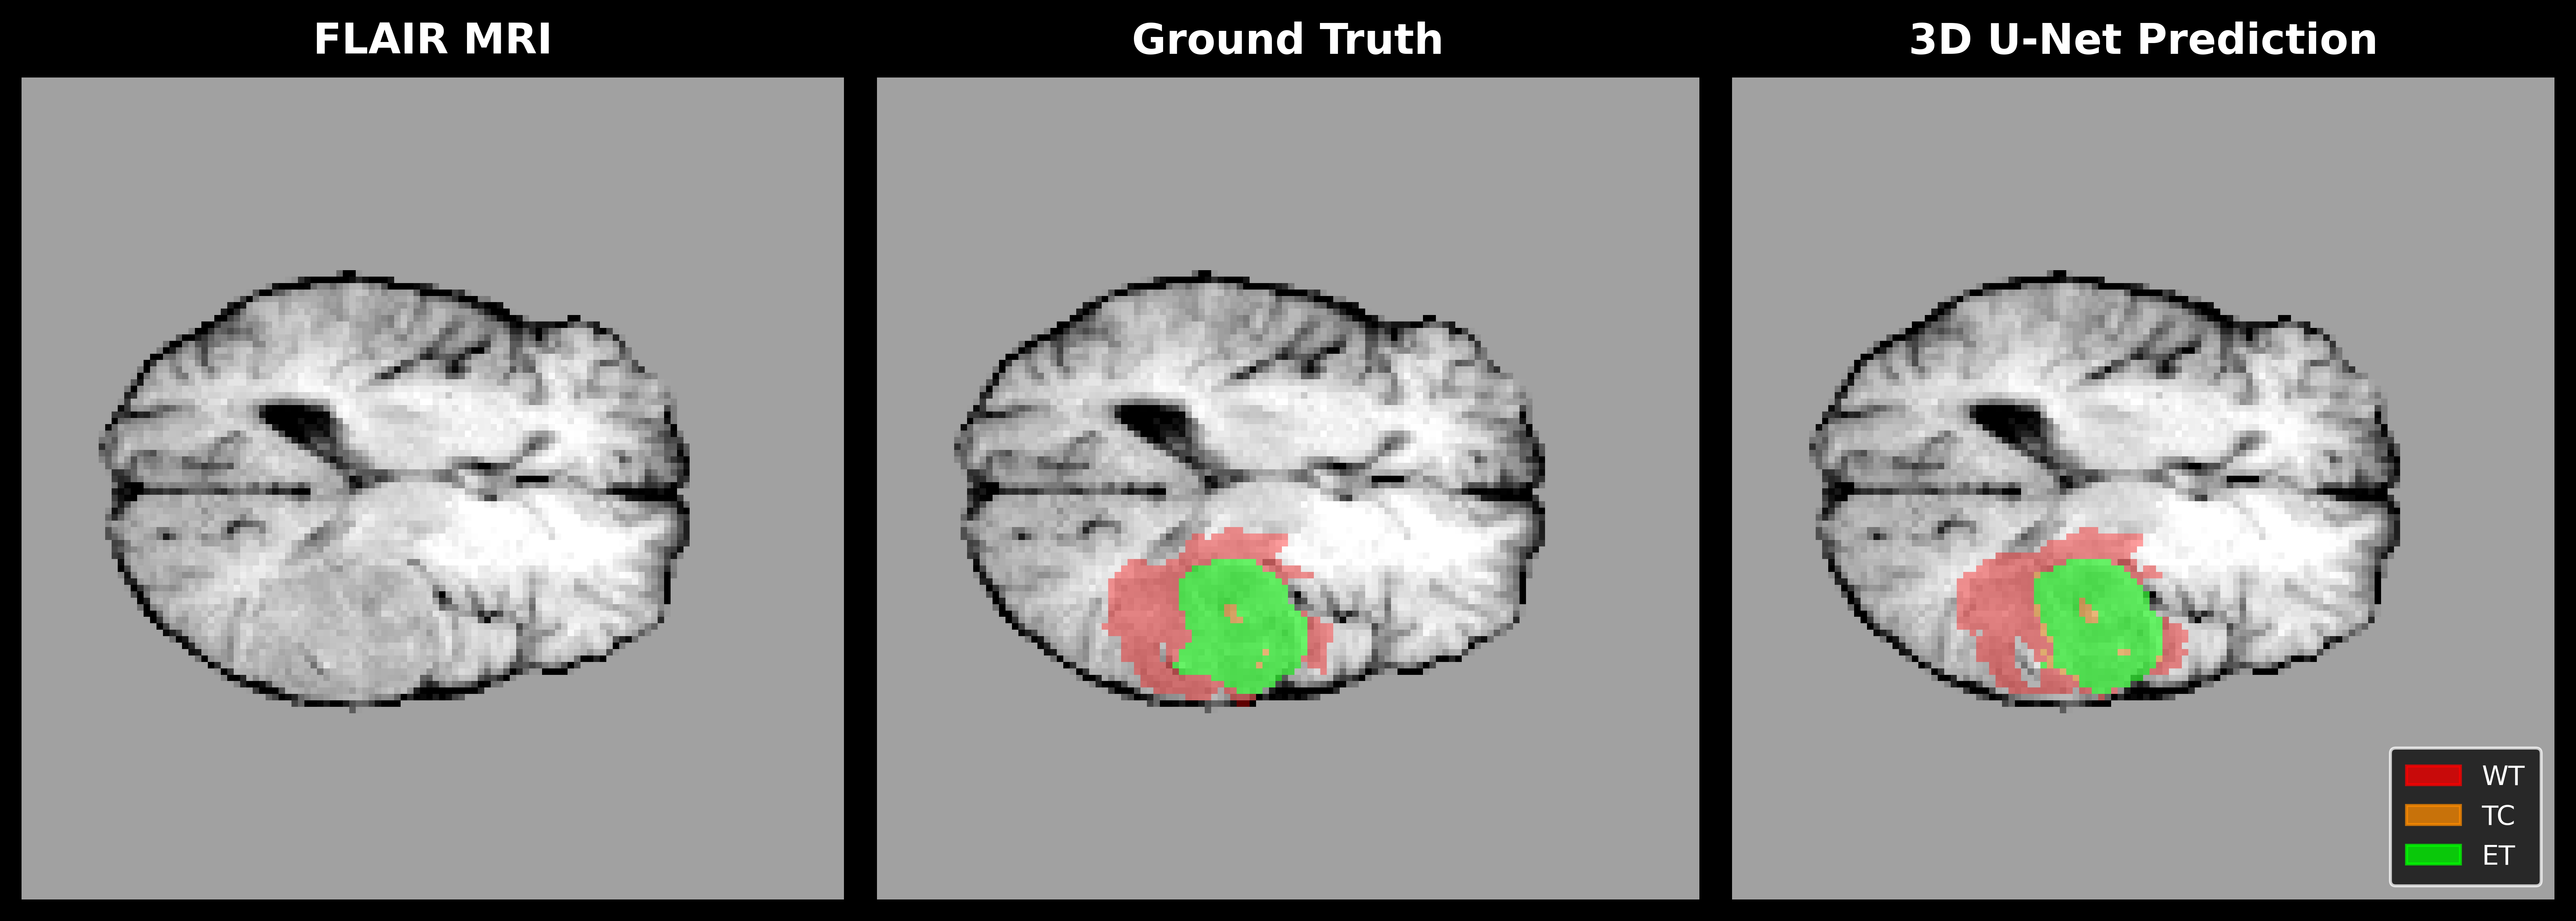

Saved: C:\Users\eraze\Saved\Patient_173_Axial_600dpi.png
Saved: C:\Users\eraze\Saved\Patient_173_Axial.pdf
Best Coronal slice: 54


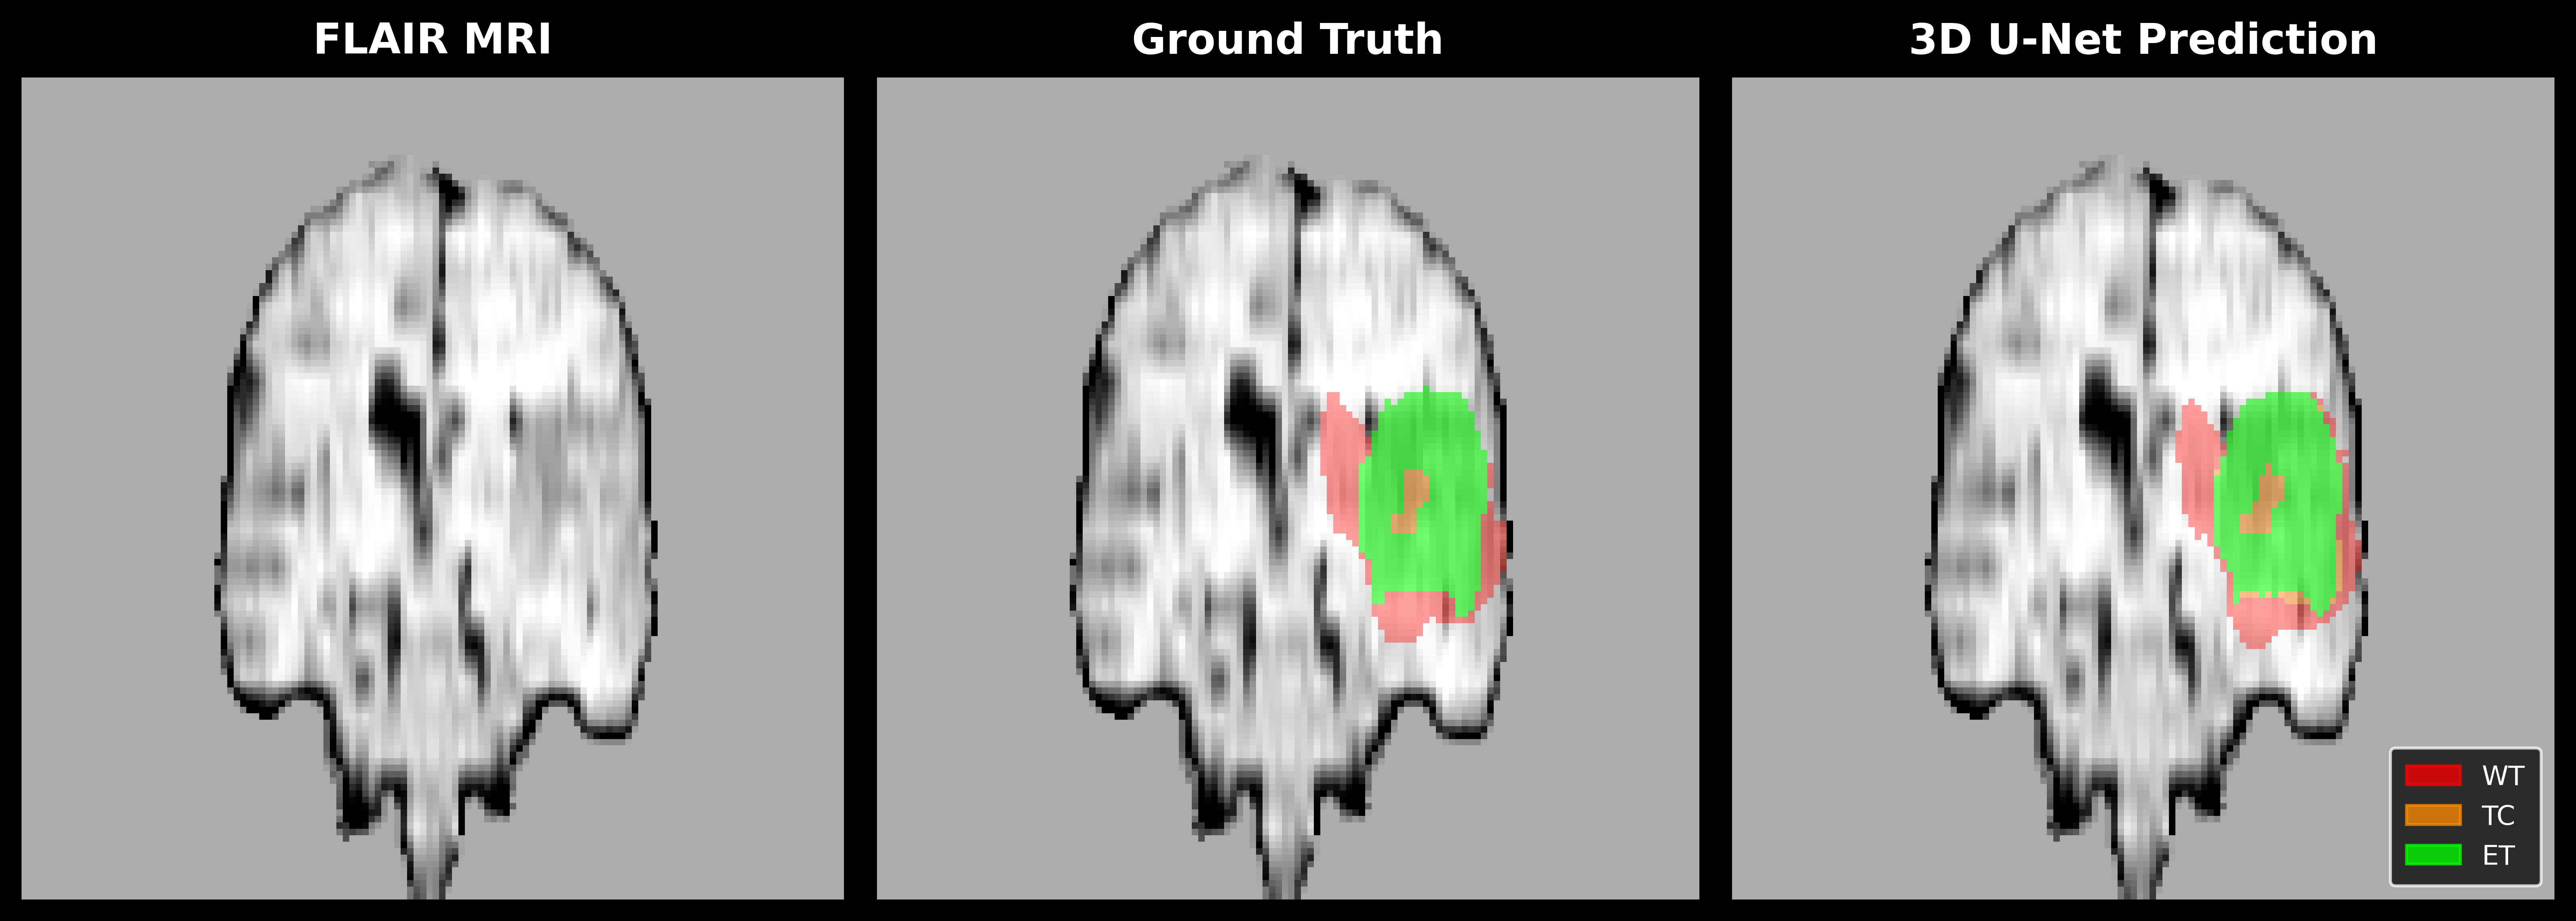

Saved: C:\Users\eraze\Saved\Patient_173_Coronal_600dpi.png
Saved: C:\Users\eraze\Saved\Patient_173_Coronal.pdf
Best Sagittal slice: 60


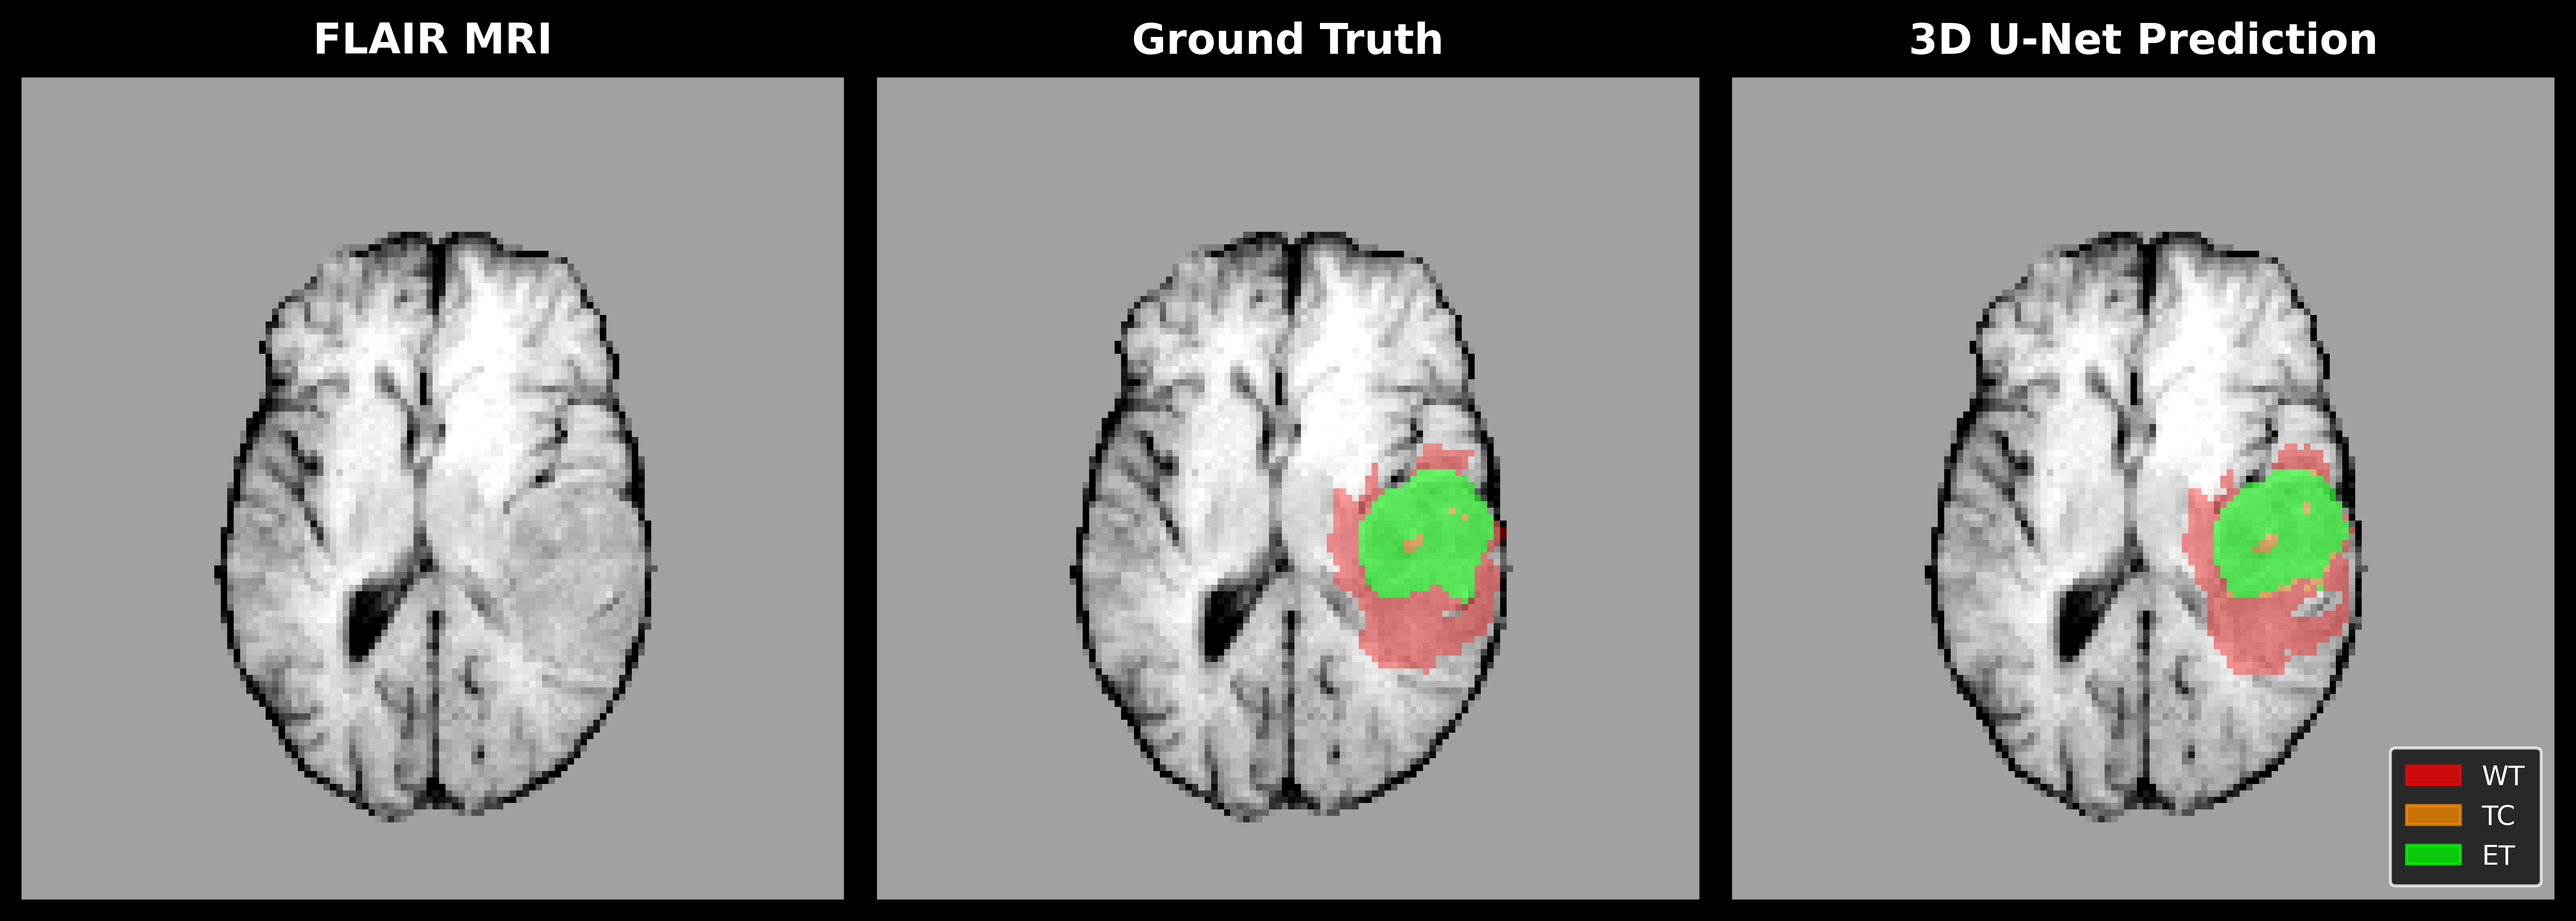

Saved: C:\Users\eraze\Saved\Patient_173_Sagittal_600dpi.png
Saved: C:\Users\eraze\Saved\Patient_173_Sagittal.pdf

PATIENT 173 COMPLETED — NO HEADER


In [85]:
# ============================================================
# PATIENT 173 — NO HEADER
# AXIAL + CORONAL + SAGITTAL
# 600 DPI
# ============================================================

patient_number = 173

# ------------------------------------------------------------
# Load patient
# ------------------------------------------------------------

model.eval()

sample = test_loader.dataset[
    patient_number - 1
]

image = sample["image"].unsqueeze(0).to(device)
label = sample["label"].unsqueeze(0).to(device)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

with torch.no_grad():
    output = model(image)

prediction = (
    torch.sigmoid(output) > 0.5
).float()

pred_np = prediction[0].cpu().numpy()
gt_np = label[0].cpu().numpy()

# ------------------------------------------------------------
# FLAIR
# ------------------------------------------------------------

flair = (
    image[0, 0]
    .detach()
    .cpu()
    .numpy()
)

flair = (
    flair - flair.min()
) / (
    flair.max() - flair.min() + 1e-8
)

# ------------------------------------------------------------
# Label maps
# ------------------------------------------------------------

gt_label = make_label_map(
    gt_np,
    flair.shape
)

pred_label = make_label_map(
    pred_np,
    flair.shape
)

combined = np.maximum(
    gt_label,
    pred_label
)

# ============================================================
# FUNCTION: SAVE ONE PLANE
# ============================================================

def save_patient_173_plane(
    flair_view,
    gt_view,
    pred_view,
    plane_name
):

    # --------------------------------------------------------
    # Crop background
    # --------------------------------------------------------

    (
        flair_view,
        gt_view,
        pred_view
    ) = crop_brain(
        flair_view,
        gt_view,
        pred_view
    )

    # --------------------------------------------------------
    # Intensity
    # --------------------------------------------------------

    vmin = np.percentile(
        flair_view,
        1
    )

    vmax = np.percentile(
        flair_view,
        99
    )

    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(12.0, 4.7),
        dpi=600,
        facecolor="black"
    )

    for ax in axes:
        ax.set_facecolor("black")

    H, W = flair_view.shape

    extent = [
        0,
        W,
        H,
        0
    ]

    # ========================================================
    # FLAIR
    # ========================================================

    axes[0].imshow(
        flair_view,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        extent=extent,
        aspect="equal"
    )

    axes[0].set_title(
        "FLAIR MRI",
        color="white",
        fontsize=14,
        fontweight="bold",
        pad=8
    )

    # ========================================================
    # GROUND TRUTH
    # ========================================================

    axes[1].imshow(
        flair_view,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        extent=extent,
        aspect="equal"
    )

    axes[1].imshow(
        gt_view,
        cmap=mask_cmap,
        vmin=0,
        vmax=3,
        interpolation="nearest",
        extent=extent,
        aspect="equal"
    )

    axes[1].set_title(
        "Ground Truth",
        color="white",
        fontsize=14,
        fontweight="bold",
        pad=8
    )

    # ========================================================
    # PREDICTION
    # ========================================================

    axes[2].imshow(
        flair_view,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        extent=extent,
        aspect="equal"
    )

    axes[2].imshow(
        pred_view,
        cmap=mask_cmap,
        vmin=0,
        vmax=3,
        interpolation="nearest",
        extent=extent,
        aspect="equal"
    )

    axes[2].set_title(
        "3D U-Net Prediction",
        color="white",
        fontsize=14,
        fontweight="bold",
        pad=8
    )

    # ========================================================
    # AXES
    # ========================================================

    for ax in axes:

        ax.set_xlim(
            0,
            W
        )

        ax.set_ylim(
            H,
            0
        )

        ax.set_aspect(
            "equal",
            adjustable="box"
        )

        ax.axis("off")

    # ========================================================
    # LEGEND
    # ========================================================

    legend = axes[2].legend(
        handles=legend_elements,
        loc="lower right",
        fontsize=9,
        frameon=True,
        facecolor="black",
        edgecolor="white",
        framealpha=0.75,
        borderpad=0.6
    )

    for text in legend.get_texts():
        text.set_color("white")

    # ========================================================
    # IMPORTANT:
    # NO PATIENT NAME
    # NO DSC
    # NO HD95
    # NO GLOBAL TITLE
    # ========================================================

    plt.subplots_adjust(
        left=0.01,
        right=0.99,
        top=0.99,
        bottom=0.01,
        wspace=0.04
    )

    # ========================================================
    # SAVE
    # ========================================================

    os.makedirs(
        "Saved",
        exist_ok=True
    )

    png_path = (
        f"Saved/Patient_173_"
        f"{plane_name}_600dpi.png"
    )

    pdf_path = (
        f"Saved/Patient_173_"
        f"{plane_name}.pdf"
    )

    plt.savefig(
        png_path,
        dpi=600,
        bbox_inches="tight",
        facecolor="black",
        pad_inches=0.02
    )

    plt.savefig(
        pdf_path,
        bbox_inches="tight",
        facecolor="black",
        pad_inches=0.02
    )

    plt.show()

    print(
        f"Saved: {os.path.abspath(png_path)}"
    )

    print(
        f"Saved: {os.path.abspath(pdf_path)}"
    )


# ============================================================
# AXIAL
# ============================================================

axial_score = combined.sum(
    axis=(0, 1)
)

z = int(
    np.argmax(axial_score)
)

print("Best Axial slice:", z)

save_patient_173_plane(
    flair[:, :, z],
    gt_label[:, :, z],
    pred_label[:, :, z],
    "Axial"
)

# ============================================================
# CORONAL
# ============================================================

coronal_score = combined.sum(
    axis=(0, 2)
)

y = int(
    np.argmax(coronal_score)
)

print("Best Coronal slice:", y)

flair_coronal = np.rot90(
    flair[:, y, :]
)

gt_coronal = np.rot90(
    gt_label[:, y, :]
)

pred_coronal = np.rot90(
    pred_label[:, y, :]
)

save_patient_173_plane(
    flair_coronal,
    gt_coronal,
    pred_coronal,
    "Coronal"
)

# ============================================================
# SAGITTAL
# ============================================================

sagittal_score = combined.sum(
    axis=(0, 1)
)

x = int(
    np.argmax(sagittal_score)
)

print("Best Sagittal slice:", x)

flair_sagittal = np.rot90(
    flair[:, :, x]
)

gt_sagittal = np.rot90(
    gt_label[:, :, x]
)

pred_sagittal = np.rot90(
    pred_label[:, :, x]
)

save_patient_173_plane(
    flair_sagittal,
    gt_sagittal,
    pred_sagittal,
    "Sagittal"
)

print("\n============================================")
print("PATIENT 173 COMPLETED — NO HEADER")
print("============================================")